In [1]:
# ── CELL 1: Download Franken + Merge into Glyph2025 ──────────────
# Fix applied: tar.extractall(filter='data') — Python 3.14 safe
import os, tarfile, urllib.request, shutil, glob
from PIL import Image

os.chdir("/kaggle/working")
print(f"Working directory: {os.getcwd()}")

# ── Paths ─────────────────────────────────────────────────────────
hiero_src   = "/kaggle/input/datasets/shaemhasanshakib/egyptian-hieroglyphic-image-dataset/EgyptianHieroglyphicText-main/dataset"
franken_dir = "/kaggle/working/GlyphFranken2025"
merged_dir  = "/kaggle/working/Glyph2025"

# ── STEP 1: Download Franken ──────────────────────────────────────
print("\n[1/3] Downloading Franken dataset...")
url             = "http://jvgemert.github.io/pub/EgyptianHieroglyphDataset.tar.gz"
compressed_file = "EgyptianHieroglyphDataset.tar.gz"
extracted_dir   = "EgyptianHieroglyphDataset"

if not os.path.exists(compressed_file):
    urllib.request.urlretrieve(url, compressed_file)
    print("     Downloaded ✓")

if not os.path.exists(extracted_dir):
    with tarfile.open(compressed_file, "r:gz") as tar:
        tar.extractall(filter='data')   # Fix #3: Python 3.14 safe
    print("     Extracted ✓")

base_path = os.path.join(extracted_dir, "ExampleSet7")
test_dir  = os.path.join(base_path, "test")
train_dir = os.path.join(base_path, "train")

for file in os.listdir(test_dir):
    if file.endswith(".png"):
        parts = file.split("_")
        if len(parts) < 2:
            continue
        target_folder = parts[1].split(".")[0]
        target_path   = os.path.join(train_dir, target_folder)
        os.makedirs(target_path, exist_ok=True)
        shutil.move(os.path.join(test_dir, file),
                    os.path.join(target_path, file))

if not os.path.exists(franken_dir):
    shutil.move(train_dir, franken_dir)
shutil.rmtree(extracted_dir, ignore_errors=True)
if os.path.exists(compressed_file):
    os.remove(compressed_file)

franken_classes = [d for d in os.listdir(franken_dir)
                   if os.path.isdir(os.path.join(franken_dir, d))]
franken_imgs    = sum(
    len([f for f in os.listdir(os.path.join(franken_dir, c))
         if f.lower().endswith(('.jpg','.jpeg','.png'))])
    for c in franken_classes)
print(f"     GlyphFranken2025: {len(franken_classes)} classes, "
      f"{franken_imgs} images ✓")

# ── STEP 2: Merge both into Glyph2025 ────────────────────────────
print("\n[2/3] Merging datasets...")
os.makedirs(merged_dir, exist_ok=True)

def merge_into(src_folder, dest_folder):
    copied = 0
    for root, dirs, files in os.walk(src_folder):
        # Fix #4: skip root level — only process class subfolders
        rel_path = os.path.relpath(root, src_folder)
        if rel_path == '.':
            continue          # skip root to prevent dest_folder/.. bug
        rel_path_lower = rel_path.lower()
        target_path    = os.path.join(dest_folder, rel_path_lower)
        os.makedirs(target_path, exist_ok=True)
        for file in files:
            if file.lower().endswith(('.jpg','.jpeg','.png')):
                src_file  = os.path.join(root, file)
                dest_file = os.path.join(target_path, file.lower())
                if not os.path.exists(dest_file):
                    shutil.copy2(src_file, dest_file)
                    copied += 1
                    if copied % 1000 == 0:
                        print(f"     Copied {copied} images...")
    return copied

c1 = merge_into(franken_dir, merged_dir)
c2 = merge_into(hiero_src,   merged_dir)
print(f"     From Franken : {c1} images")
print(f"     From Hiero   : {c2} images")
print(f"     Merge complete ✓")

# ── STEP 3: Resize all to 300x300 (B3 native size) ───────────────
print("\n[3/3] Resizing all images to 300×300...")
processed, skipped = 0, 0

for ext in ['.png', '.jpg', '.jpeg']:
    for filename in glob.iglob(merged_dir + f'/**/*{ext}',
                               recursive=True):
        try:
            im    = Image.open(filename).convert("RGB")
            size  = im.size
            ratio = float(300) / max(size)
            new_size = tuple([int(x * ratio) for x in size])
            im    = im.resize(new_size, Image.LANCZOS)
            new_im = Image.new("RGB", (300, 300), color=(0, 0, 0))
            new_im.paste(im, ((300 - new_size[0]) // 2,
                               (300 - new_size[1]) // 2))
            new_im.save(filename)
            processed += 1
            if processed % 1000 == 0:
                print(f"     Resized {processed} images...")
        except Exception as e:
            skipped += 1
            print(f"     ⚠ Skipped {filename}: {e}")  # Fix #16

print(f"     Done — {processed} resized, {skipped} skipped ✓")

# ── Summary ───────────────────────────────────────────────────────
import numpy as np
classes = [d for d in os.listdir(merged_dir)
           if os.path.isdir(os.path.join(merged_dir, d))]
counts  = [len([f for f in os.listdir(os.path.join(merged_dir, c))
                if f.lower().endswith(('.jpg','.jpeg','.png'))])
           for c in classes]
total   = sum(counts)

print("\n" + "="*55)
print(f"✅ Glyph2025 ready!")
print(f"   Path          : {merged_dir}")
print(f"   Total classes : {len(classes)}")
print(f"   Total images  : {total}")
print(f"   Avg per class : {np.mean(counts):.1f}")
print(f"   Min per class : {min(counts)}")
print(f"   Max per class : {max(counts)}")
print(f"   Median        : {np.median(counts):.1f}")
print("="*55)

Working directory: /kaggle/working

[1/3] Downloading Franken dataset...
     Downloaded ✓
     Extracted ✓
     GlyphFranken2025: 172 classes, 4039 images ✓

[2/3] Merging datasets...
     Copied 1000 images...
     Copied 2000 images...
     Copied 3000 images...
     Copied 4000 images...
     Copied 1000 images...
     Copied 2000 images...
     Copied 3000 images...
     Copied 4000 images...
     Copied 5000 images...
     Copied 6000 images...
     Copied 7000 images...
     Copied 8000 images...
     Copied 9000 images...
     From Franken : 4039 images
     From Hiero   : 9703 images
     Merge complete ✓

[3/3] Resizing all images to 300×300...
     Resized 1000 images...
     Resized 2000 images...
     Resized 3000 images...
     Resized 4000 images...
     Resized 5000 images...
     Resized 6000 images...
     Resized 7000 images...
     Resized 8000 images...
     Resized 9000 images...
     Resized 10000 images...
     Resized 11000 images...
     Resized 12000 images..

In [2]:
# ── CELL 2 (Fixed ): Stratified Split — fully manual ───────────
import os, json
import numpy as np

data_dir = "/kaggle/working/Glyph2025"

# ── Scan all classes and images ───────────────────────────────────
classes      = sorted([d for d in os.listdir(data_dir)
                       if os.path.isdir(os.path.join(data_dir, d))])
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
idx_to_class = {idx: cls for idx, cls in enumerate(classes)}
num_classes  = len(classes)

all_image_paths = []
all_labels      = []

for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    imgs = sorted([f for f in os.listdir(cls_path)
                   if f.lower().endswith(('.jpg','.jpeg','.png'))])
    for img in imgs:
        all_image_paths.append(os.path.join(cls_path, img))
        all_labels.append(class_to_idx[cls])

all_image_paths = np.array(all_image_paths)
all_labels      = np.array(all_labels)
total_images    = len(all_image_paths)
counts          = np.bincount(all_labels)

# ── Dataset stats ─────────────────────────────────────────────────
print("="*55)
print(f"Total classes   : {num_classes}")
print(f"Total images    : {total_images}")
print(f"Avg per class   : {counts.mean():.1f}")
print(f"Min per class   : {counts.min()} → {classes[counts.argmin()]}")
print(f"Max per class   : {counts.max()} → {classes[counts.argmax()]}")
print(f"Median          : {np.median(counts):.1f}")
print("="*55)

# ── Fully manual stratified split ────────────────────────────────
# For each class independently:
#   1 image  → train only
#   2 images → train + val
#   3 images → train + val + test
#   4+ images → 75% train, 15% val, 10% test (proportional)

print("\nPerforming per-class stratified split (75/15/10)...")
np.random.seed(42)

X_train, y_train = [], []
X_val,   y_val   = [], []
X_test,  y_test  = [], []

for cls_idx in range(num_classes):
    mask     = all_labels == cls_idx
    cls_imgs = all_image_paths[mask].copy()
    np.random.shuffle(cls_imgs)
    n = len(cls_imgs)

    if n == 1:
        # Only 1 image — goes to train
        X_train.append(cls_imgs[0])
        y_train.append(cls_idx)

    elif n == 2:
        # 2 images — train + val
        X_train.append(cls_imgs[0]); y_train.append(cls_idx)
        X_val.append(cls_imgs[1]);   y_val.append(cls_idx)

    elif n == 3:
        # 3 images — train + val + test
        X_train.append(cls_imgs[0]); y_train.append(cls_idx)
        X_val.append(cls_imgs[1]);   y_val.append(cls_idx)
        X_test.append(cls_imgs[2]);  y_test.append(cls_idx)

    else:
        # 4+ images — proportional 75/15/10 split
        n_test  = max(1, round(n * 0.10))
        n_val   = max(1, round(n * 0.15))
        n_train = n - n_val - n_test

        X_train.extend(cls_imgs[:n_train])
        y_train.extend([cls_idx] * n_train)
        X_val.extend(cls_imgs[n_train:n_train + n_val])
        y_val.extend([cls_idx] * n_val)
        X_test.extend(cls_imgs[n_train + n_val:])
        y_test.extend([cls_idx] * n_test)

# Convert to arrays
X_train = np.array(X_train); y_train = np.array(y_train)
X_val   = np.array(X_val);   y_val   = np.array(y_val)
X_test  = np.array(X_test);  y_test  = np.array(y_test)

total = len(X_train) + len(X_val) + len(X_test)
print(f"Train : {len(X_train):>5} images ({len(X_train)/total*100:.1f}%)")
print(f"Val   : {len(X_val):>5} images ({len(X_val)/total*100:.1f}%)")
print(f"Test  : {len(X_test):>5} images ({len(X_test)/total*100:.1f}%)")
print(f"Total : {total:>5} images")

# ── Verify class coverage ─────────────────────────────────────────
print(f"\nClasses in train : {len(np.unique(y_train))} / {num_classes}")
print(f"Classes in val   : {len(np.unique(y_val))} / {num_classes}")
print(f"Classes in test  : {len(np.unique(y_test))} / {num_classes}")
print(f"All 353 in train : "
      f"{' Yes' if len(np.unique(y_train))==num_classes else '⚠ No'}")
print(f"All 353 in val   : "
      f"{' Yes' if len(np.unique(y_val))==num_classes else '⚠ No'}")
print(f"All 353 in test  : "
      f"{'Yes' if len(np.unique(y_test))==num_classes else '⚠ No'}")

# ── Check min per class in val/test ──────────────────────────────
val_counts  = np.bincount(y_val,  minlength=num_classes)
test_counts = np.bincount(y_test, minlength=num_classes)
print(f"\nMin images per class in val  : {val_counts.min()}")
print(f"Min images per class in test : {test_counts.min()}")

# ── Save everything ───────────────────────────────────────────────
np.save("/kaggle/working/split_X_train.npy", X_train)
np.save("/kaggle/working/split_X_val.npy",   X_val)
np.save("/kaggle/working/split_X_test.npy",  X_test)
np.save("/kaggle/working/split_y_train.npy", y_train)
np.save("/kaggle/working/split_y_val.npy",   y_val)
np.save("/kaggle/working/split_y_test.npy",  y_test)

with open("/kaggle/working/class_names.json", "w") as f:
    json.dump({
        "classes"     : classes,
        "class_to_idx": class_to_idx,
        "idx_to_class": {str(k): v
                         for k, v in idx_to_class.items()},
        "num_classes" : num_classes
    }, f, indent=2)

print("\n Stratified split complete — no data leakage!")
print("   split arrays saved ✓")
print("   class_names.json  saved ✓")


Total classes   : 353
Total images    : 13742
Avg per class   : 38.9
Min per class   : 1 → a16
Max per class   : 987 → n35
Median          : 7.0

Performing per-class stratified split (75/15/10)...
Train : 10227 images (74.4%)
Val   :  2108 images (15.3%)
Test  :  1407 images (10.2%)
Total : 13742 images

Classes in train : 353 / 353
Classes in val   : 293 / 353
Classes in test  : 257 / 353
All 353 in train :  Yes
All 353 in val   : ⚠ No
All 353 in test  : ⚠ No

Min images per class in val  : 0
Min images per class in test : 0

 Stratified split complete — no data leakage!
   split arrays saved ✓
   class_names.json  saved ✓


In [3]:
# ── CELL 3 (v2): Augment Training Set — min 50 images ─────────────
import os, shutil, json
import numpy as np
from PIL import Image, ImageOps, ImageFilter
import random

X_train = np.load("/kaggle/working/split_X_train.npy")
y_train = np.load("/kaggle/working/split_y_train.npy")

with open("/kaggle/working/class_names.json") as f:
    meta = json.load(f)
classes     = meta["classes"]
num_classes = meta["num_classes"]

TRAIN_AUG_DIR = "/kaggle/working/GlyphTrain_Aug"
MIN_IMAGES    = 50    # increased from 20 to 50

# Remove old augmented folder and rebuild
if os.path.exists(TRAIN_AUG_DIR):
    shutil.rmtree(TRAIN_AUG_DIR)
    print("Old augmentation folder removed.")
os.makedirs(TRAIN_AUG_DIR, exist_ok=True)

print(f"Augmenting training set only...")
print(f"Min images per class target : {MIN_IMAGES}")
print(f"Training images before aug  : {len(X_train)}")

# ── Augmentation function ─────────────────────────────────────────
def augment_image(img):
    ops = [
        lambda x: x.rotate(random.uniform(-25, 25),
                            fillcolor=(0, 0, 0)),
        lambda x: ImageOps.mirror(x),
        lambda x: ImageOps.flip(x),
        lambda x: x.rotate(90,  fillcolor=(0, 0, 0)),
        lambda x: x.rotate(270, fillcolor=(0, 0, 0)),
        lambda x: x.filter(ImageFilter.GaussianBlur(radius=1)),
        lambda x: ImageOps.autocontrast(x),
        lambda x: x.crop((
            random.randint(0, 20), random.randint(0, 20),
            300 - random.randint(0, 20),
            300 - random.randint(0, 20)
        )).resize((300, 300), Image.LANCZOS),
    ]
    chosen = random.sample(ops, k=random.randint(1, 2))
    for op in chosen:
        try:
            img = op(img)
        except Exception:
            pass
    return img

# ── Copy + augment ────────────────────────────────────────────────
total_generated = 0
augmented_cls   = 0
copied_cls      = 0

for cls_idx in range(num_classes):
    cls_name = classes[cls_idx]
    cls_dir  = os.path.join(TRAIN_AUG_DIR, cls_name)
    os.makedirs(cls_dir, exist_ok=True)

    cls_mask  = y_train == cls_idx
    cls_paths = X_train[cls_mask]

    # Copy originals
    for img_path in cls_paths:
        fname = os.path.basename(img_path)
        dst   = os.path.join(cls_dir, fname)
        if not os.path.exists(dst):
            shutil.copy2(img_path, dst)

    n = len(cls_paths)

    if n < MIN_IMAGES:
        needed    = MIN_IMAGES - n
        aug_count = 0
        attempts  = 0
        while aug_count < needed and attempts < needed * 10:
            src_path = random.choice(cls_paths)
            try:
                img     = Image.open(src_path).convert("RGB")
                aug_img = augment_image(img)
                aug_name = (f"aug_{aug_count:04d}_"
                            f"{os.path.basename(src_path)}")
                aug_img.save(os.path.join(cls_dir, aug_name))
                aug_count       += 1
                total_generated += 1
            except Exception as e:
                print(f"     Skipped: {e}")
            attempts += 1
        augmented_cls += 1
    else:
        copied_cls += 1

# ── Stats ─────────────────────────────────────────────────────────
aug_counts = np.array([
    len([f for f in os.listdir(os.path.join(TRAIN_AUG_DIR, cls))
         if f.lower().endswith(('.jpg','.jpeg','.png'))])
    for cls in classes])

total_train = aug_counts.sum()

print(f"Classes augmented   : {augmented_cls}")
print(f"Classes untouched   : {copied_cls}")
print(f"Images generated    : {total_generated}")

print("\n" + "="*55)
print(f"GlyphTrain_Aug ready (min 50)!")
print(f"   Total classes   : {num_classes}")
print(f"   Total images    : {total_train}")
print(f"   Avg per class   : {aug_counts.mean():.1f}")
print(f"   Min per class   : {aug_counts.min()}")
print(f"   Max per class   : {aug_counts.max()}")
print(f"   Median          : {np.median(aug_counts):.1f}")
print(f"   < 50 images     : {(aug_counts < 50).sum()} classes")
print(f"   >= 50 images    : {(aug_counts >= 50).sum()} classes")
print("="*55)
print("NOTE: Val and test sets unchanged — no leakage")

Augmenting training set only...
Min images per class target : 50
Training images before aug  : 10227
Classes augmented   : 307
Classes untouched   : 46
Images generated    : 12880

GlyphTrain_Aug ready (min 50)!
   Total classes   : 353
   Total images    : 23107
   Avg per class   : 65.5
   Min per class   : 50
   Max per class   : 740
   Median          : 50.0
   < 50 images     : 0 classes
   >= 50 images    : 353 classes
NOTE: Val and test sets unchanged — no leakage


In [4]:
# ── CELL 4: Build Data Loaders ────────────────────────────────────
import os, json, random
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
print(f"GPU    : {torch.cuda.get_device_name(0)}")
print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"Deterministic mode : ON")

def set_seed(s):
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)

set_seed(42)

CFG = {
    "img_size"   : 300,
    "batch_size" : 16,
    "num_workers": 2,
    "seed"       : 42,
}

X_train = np.load("/kaggle/working/split_X_train.npy")
X_val   = np.load("/kaggle/working/split_X_val.npy")
X_test  = np.load("/kaggle/working/split_X_test.npy")
y_train = np.load("/kaggle/working/split_y_train.npy")
y_val   = np.load("/kaggle/working/split_y_val.npy")
y_test  = np.load("/kaggle/working/split_y_test.npy")

with open("/kaggle/working/class_names.json") as f:
    meta = json.load(f)

classes     = meta["classes"]
num_classes = meta["num_classes"]

print(f"\nClasses    : {num_classes}")
print(f"Train split: {len(X_train)} original images")
print(f"Val        : {len(X_val)} images")
print(f"Test       : {len(X_test)} images")

TRAIN_AUG_DIR = "/kaggle/working/GlyphTrain_Aug"

X_train_aug = []
y_train_aug = []

for cls_idx, cls_name in enumerate(classes):
    cls_dir = os.path.join(TRAIN_AUG_DIR, cls_name)
    if not os.path.isdir(cls_dir):
        continue
    imgs = [f for f in os.listdir(cls_dir)
            if f.lower().endswith(('.jpg','.jpeg','.png'))]
    for img in imgs:
        X_train_aug.append(os.path.join(cls_dir, img))
        y_train_aug.append(cls_idx)

X_train_aug = np.array(X_train_aug)
y_train_aug = np.array(y_train_aug)

print(f"Train aug  : {len(X_train_aug)} images "
      f"(original + augmented)")

class HieroglyphDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels      = labels
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        try:
            img = Image.open(img_path).convert("RGB")
        except Exception as e:
            print(f"Failed to load {img_path}: {e}")
            img = Image.new("RGB",
                            (CFG["img_size"], CFG["img_size"]),
                            (0, 0, 0))
        if self.transform:
            img = self.transform(img)
        return img, int(self.labels[idx])

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(CFG["img_size"], scale=(0.65, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(25),
    transforms.ColorJitter(brightness=0.4, contrast=0.4,
                           saturation=0.2),
    transforms.RandomGrayscale(p=0.15),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.2)),
])

val_tf = transforms.Compose([
    transforms.Resize((CFG["img_size"], CFG["img_size"])),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_dataset = HieroglyphDataset(X_train_aug, y_train_aug, train_tf)
val_dataset   = HieroglyphDataset(X_val,       y_val,       val_tf)
test_dataset  = HieroglyphDataset(X_test,      y_test,      val_tf)

print(f"\nTrain dataset : {len(train_dataset)} images")
print(f"Val dataset   : {len(val_dataset)} images")
print(f"Test dataset  : {len(test_dataset)} images")

class_counts  = np.bincount(y_train_aug,
                             minlength=num_classes).astype(float)
class_weights = 1.0 / (class_counts + 1e-6)
sample_w      = [class_weights[l] for l in y_train_aug]
sampler       = WeightedRandomSampler(
    sample_w, len(sample_w), replacement=True)

train_loader = DataLoader(
    train_dataset,
    batch_size=CFG["batch_size"],
    sampler=sampler,
    num_workers=CFG["num_workers"],
    pin_memory=True)

val_loader = DataLoader(
    val_dataset,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=True)

test_loader = DataLoader(
    test_dataset,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=True)

print(f"\nTrain batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")
print(f"\nData loaders ready.")

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB
Deterministic mode : ON

Classes    : 353
Train split: 10227 original images
Val        : 2108 images
Test       : 1407 images
Train aug  : 23107 images (original + augmented)

Train dataset : 23107 images
Val dataset   : 2108 images
Test dataset  : 1407 images

Train batches : 1445
Val batches   : 132
Test batches  : 88

Data loaders ready.


Memory cleared.
Model            : EfficientNet-B3 (gradual unfreeze)
Trainable params : 1,935,713 / 12,631,945
Phase 1          : Head only (5 epochs)

 Ep  Phase   T-Loss   T-Acc   V-Loss   V-Acc         LR    Time
  1      1   4.5421   0.204      nan   0.110   9.14e-04 141.1s <- best
  2      1   3.6255   0.356      nan   0.203   6.89e-04 135.8s <- best
  3      1   3.3586   0.418      nan   0.246   4.11e-04 134.4s <- best
  4      1   3.1897   0.454      nan   0.294   1.86e-04 132.9s <- best
  5      1   3.0840   0.480      nan   0.303   1.00e-04 138.8s <- best

Phase 2 — Full backbone unfreeze at epoch 6
Trainable params : 12,631,945 / 12,631,945
Optimizer reset with differential LR.

  6      2   2.7642   0.563      nan   0.421   2.00e-05 266.5s <- best
  7      2   2.3880   0.658      nan   0.520   3.00e-05 265.7s <- best
  8      2   2.1220   0.730   2.4313   0.628   3.00e-05 266.1s <- best
  9      2   1.9229   0.784   2.1412   0.707   3.00e-05 266.9s <- best
 10      2   1.75

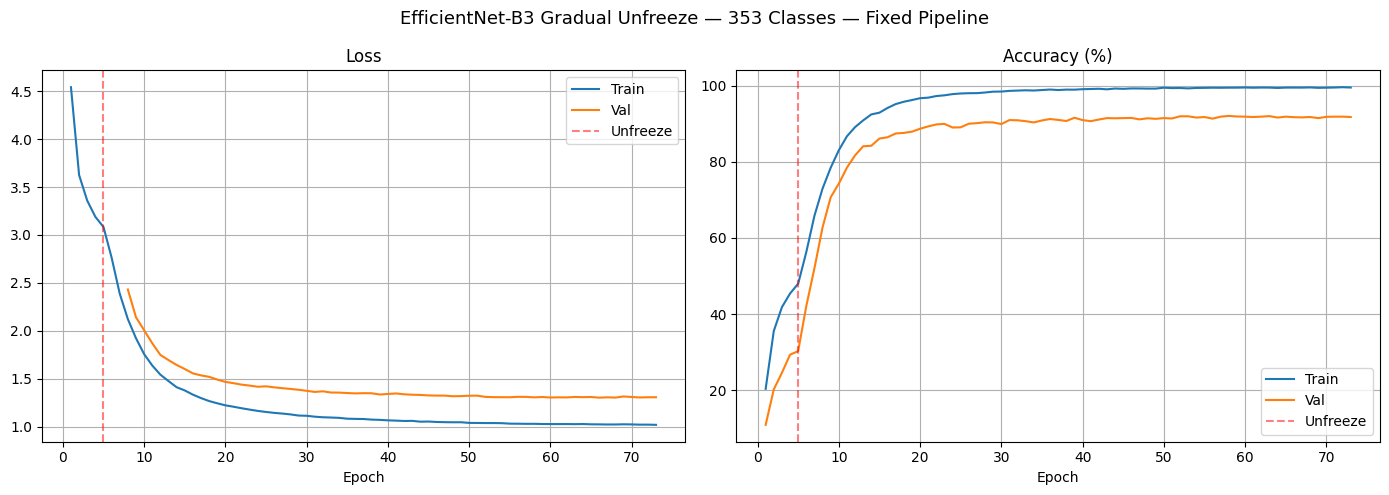

Saved: efficientnet_b3_best.pth
Saved: efficientnet_b3_curves.png
Saved: efficientnet_b3_history.json


In [6]:
# ── CELL 5 (Run 2 restored): EfficientNet-B3 Gradual Unfreeze ─────
import os, copy, time, gc, json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import matplotlib.pyplot as plt

OUTPUT = "/kaggle/working/"
gc.collect()
torch.cuda.empty_cache()
print("Memory cleared.")

model = models.efficientnet_b3(
    weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)

# Phase 1: freeze backbone
for param in model.features.parameters():
    param.requires_grad = False
for param in model.classifier.parameters():
    param.requires_grad = True

in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(in_features, 1024),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(1024, num_classes),
)

model = model.to(DEVICE)

trainable    = sum(p.numel() for p in model.parameters()
                   if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Model            : EfficientNet-B3 (gradual unfreeze)")
print(f"Trainable params : {trainable:,} / {total_params:,}")
print(f"Phase 1          : Head only (5 epochs)")

HEAD_EPOCHS    = 5
TOTAL_EPOCHS   = 80
PATIENCE       = 15
UNFREEZE_EPOCH = HEAD_EPOCHS + 1

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scaler    = torch.amp.GradScaler("cuda")

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3, weight_decay=1e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=HEAD_EPOCHS, eta_min=1e-4)

def train_epoch(model, loader):
    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.amp.autocast("cuda"):
            out  = model(imgs)
            loss = criterion(out, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        loss_sum += loss.item() * imgs.size(0)
        correct  += out.argmax(1).eq(labels).sum().item()
        total    += imgs.size(0)
    return loss_sum / total, correct / total

def eval_epoch(model, loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            with torch.amp.autocast("cuda"):
                out  = model(imgs)
                loss = criterion(out, labels)
            loss_sum += loss.item() * imgs.size(0)
            correct  += out.argmax(1).eq(labels).sum().item()
            total    += imgs.size(0)
    return loss_sum / total, correct / total

history  = {"train_loss":[], "train_acc":[],
            "val_loss":[],   "val_acc":[]}
best_acc = 0.0
best_wts = copy.deepcopy(model.state_dict())
patience_counter = 0
phase    = 1

print("\n" + "="*75)
print(f"{'Ep':>3} {'Phase':>6} {'T-Loss':>8} {'T-Acc':>7} "
      f"{'V-Loss':>8} {'V-Acc':>7} {'LR':>10} {'Time':>7}")
print("="*75)

for epoch in range(1, TOTAL_EPOCHS + 1):

    if epoch == UNFREEZE_EPOCH:
        phase = 2
        print(f"\nPhase 2 — Full backbone unfreeze at epoch {epoch}")

        for param in model.parameters():
            param.requires_grad = True

        trainable = sum(p.numel() for p in model.parameters()
                        if p.requires_grad)
        print(f"Trainable params : {trainable:,} / {total_params:,}")

        optimizer = optim.AdamW([
            {"params": model.features.parameters(),
             "lr": 3e-5},
            {"params": model.classifier.parameters(),
             "lr": 1e-4},
        ], weight_decay=1e-4)

        remaining = TOTAL_EPOCHS - UNFREEZE_EPOCH + 1

        def lr_lambda(ep):
            if ep < 3:
                return (ep + 1) / 3
            progress = (ep - 3) / max(remaining - 3, 1)
            return 0.5 * (1 + np.cos(np.pi * progress))

        scheduler = optim.lr_scheduler.LambdaLR(
            optimizer, lr_lambda)
        print("Optimizer reset with differential LR.\n")

    t0 = time.time()

    tr_loss, tr_acc = train_epoch(model, train_loader)
    vl_loss, vl_acc = eval_epoch(model,  val_loader)
    scheduler.step()

    gc.collect()
    torch.cuda.empty_cache()

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(vl_loss)
    history["val_acc"].append(vl_acc)

    lr      = optimizer.param_groups[0]["lr"]
    elapsed = time.time() - t0
    flag    = " <- best" if vl_acc > best_acc else ""

    print(f"{epoch:>3} {phase:>6} {tr_loss:>8.4f} {tr_acc:>7.3f} "
          f"{vl_loss:>8.4f} {vl_acc:>7.3f} "
          f"{lr:>10.2e} {elapsed:>5.1f}s{flag}")

    if vl_acc > best_acc:
        best_acc = vl_acc
        best_wts = copy.deepcopy(model.state_dict())
        torch.save(best_wts,
                   OUTPUT + "efficientnet_b3_best.pth")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE and epoch > UNFREEZE_EPOCH:
            print(f"\nEarly stopping at epoch {epoch} "
                  f"(no improvement for {PATIENCE} epochs)")
            break

model.load_state_dict(best_wts)
best_epoch = int(np.argmax(history["val_acc"])) + 1

print(f"\nBest val accuracy : {best_acc:.4f} ({best_acc*100:.2f}%)")
print(f"Best epoch        : {best_epoch}")

epochs_ran = len(history["train_loss"])
fig, axes  = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, epochs_ran+1),
             history["train_loss"], label="Train")
axes[0].plot(range(1, epochs_ran+1),
             history["val_loss"],   label="Val")
axes[0].axvline(x=HEAD_EPOCHS, color='red',
                linestyle='--', alpha=0.5, label='Unfreeze')
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(range(1, epochs_ran+1),
             [a*100 for a in history["train_acc"]], label="Train")
axes[1].plot(range(1, epochs_ran+1),
             [a*100 for a in history["val_acc"]],   label="Val")
axes[1].axvline(x=HEAD_EPOCHS, color='red',
                linestyle='--', alpha=0.5, label='Unfreeze')
axes[1].set_title("Accuracy (%)")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True)

plt.suptitle(
    "EfficientNet-B3 Gradual Unfreeze — 353 Classes — Fixed Pipeline",
    fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT + "efficientnet_b3_curves.png",
            dpi=100, bbox_inches='tight')
plt.show()

with open(OUTPUT + "efficientnet_b3_history.json", "w") as f:
    json.dump(history, f)

print("Saved: efficientnet_b3_best.pth")
print("Saved: efficientnet_b3_curves.png")
print("Saved: efficientnet_b3_history.json")

Loading EfficientNet-B3 best weights...
Loaded ✓

  TEST SET RESULTS — EfficientNet-B3
  353 classes | 1407 images
  Top-1 Accuracy : 91.97%
  Top-3 Accuracy : 96.38%
  Top-5 Accuracy : 97.30%

── 10 Worst classes (F1) ────────────────────────────────────
  a17                  F1: 0.000  support: 1
  a26                  F1: 0.000  support: 1
  a28                  F1: 0.000  support: 1
  a9                   F1: 0.000  support: 1
  aa11                 F1: 0.000  support: 1
  aa27                 F1: 0.000  support: 1
  aa5                  F1: 0.000  support: 1
  d19                  F1: 0.000  support: 1
  d38                  F1: 0.000  support: 1
  d41                  F1: 0.000  support: 1

── 10 Best classes (F1) ─────────────────────────────────────
  w17                  F1: 1.000  support: 4
  w5                   F1: 1.000  support: 1
  w9                   F1: 1.000  support: 1
  x7                   F1: 1.000  support: 2
  x8                   F1: 1.000  support: 15
  z1 

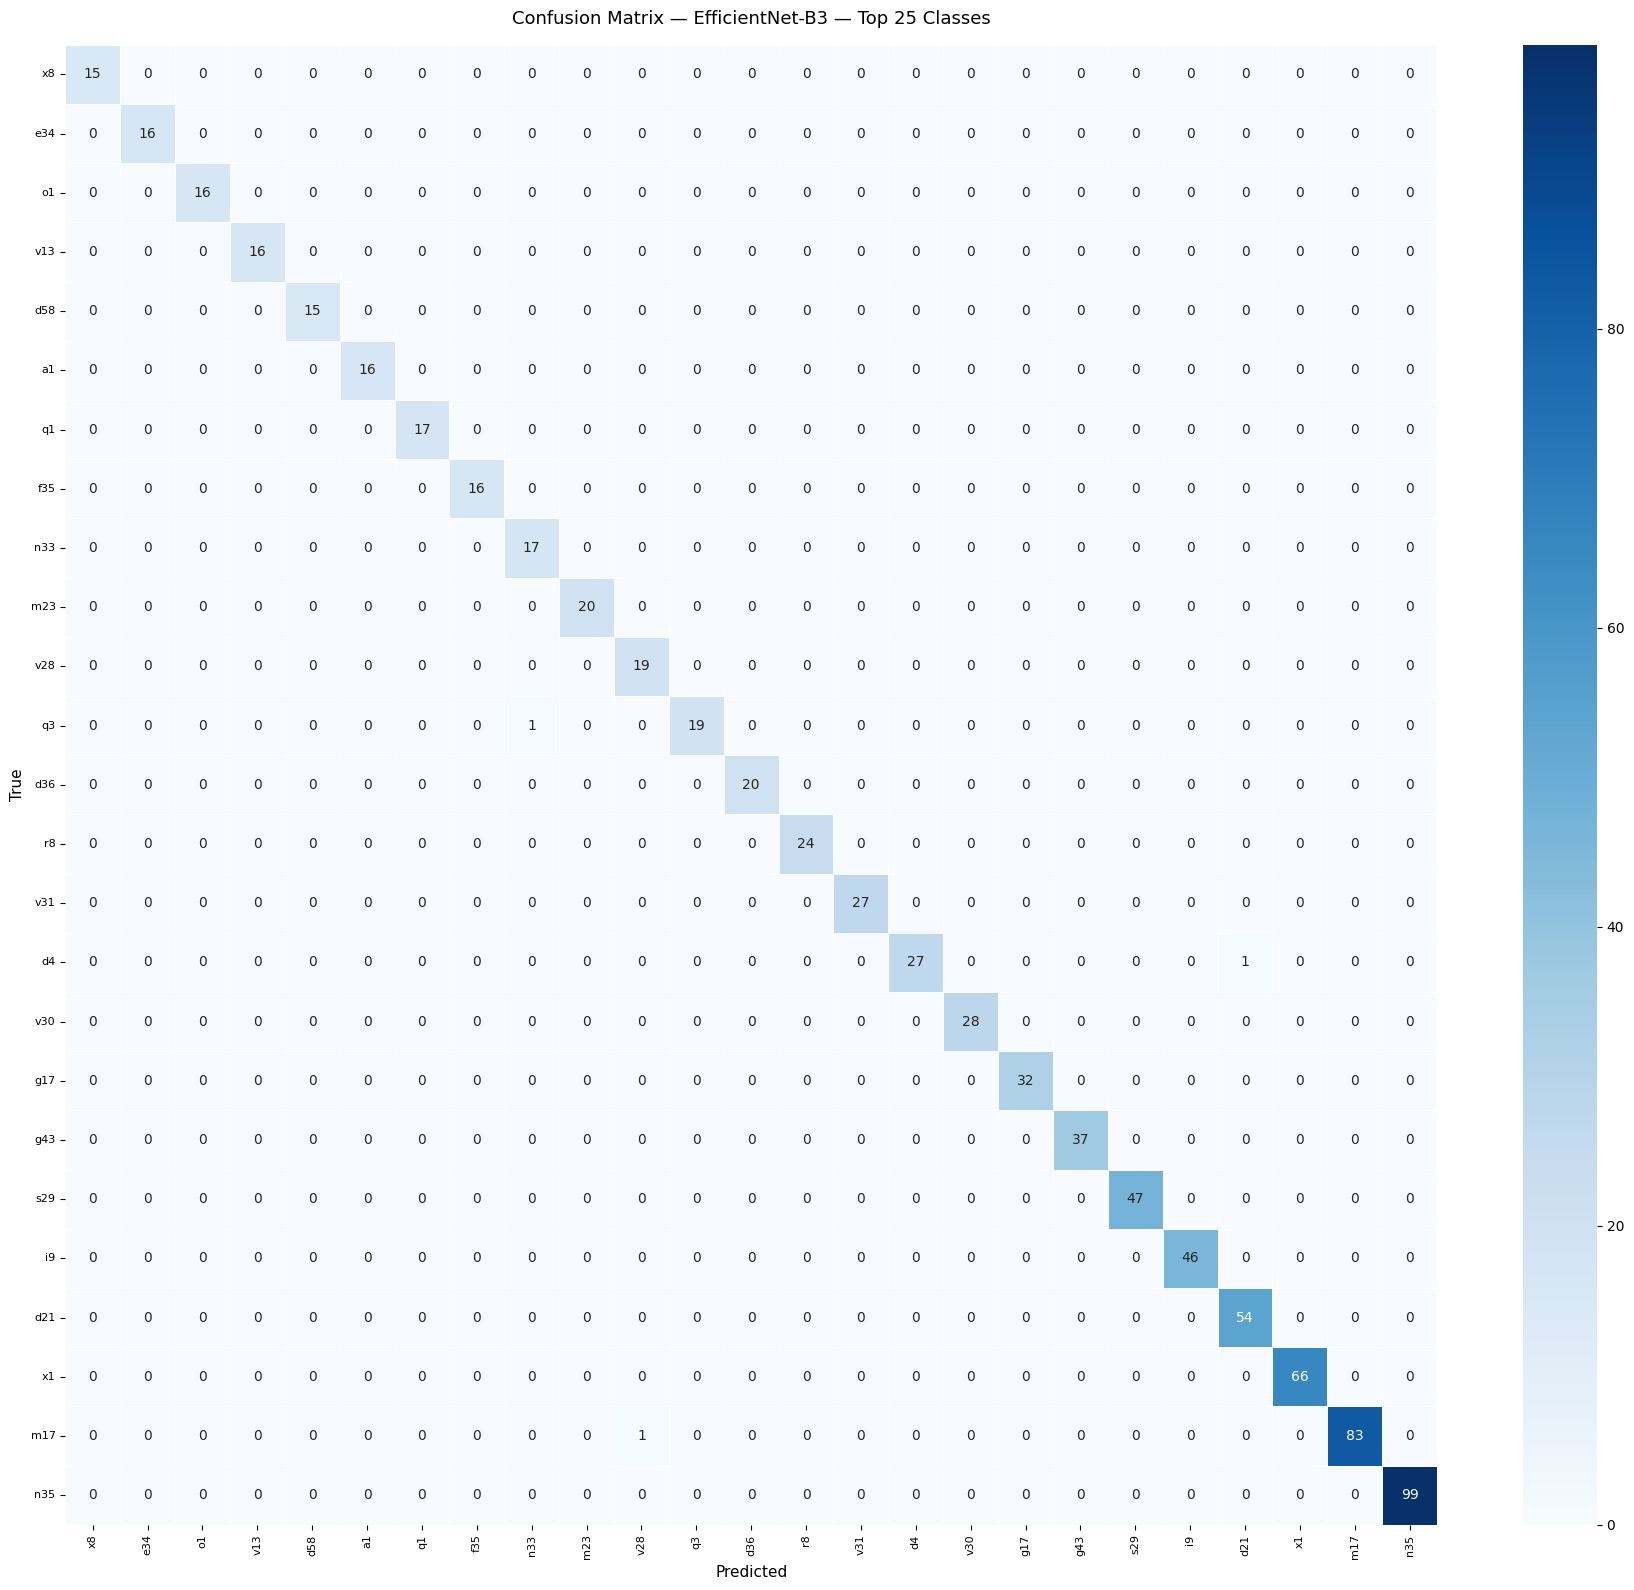

Saved: confusion_matrix_b3.png ✓


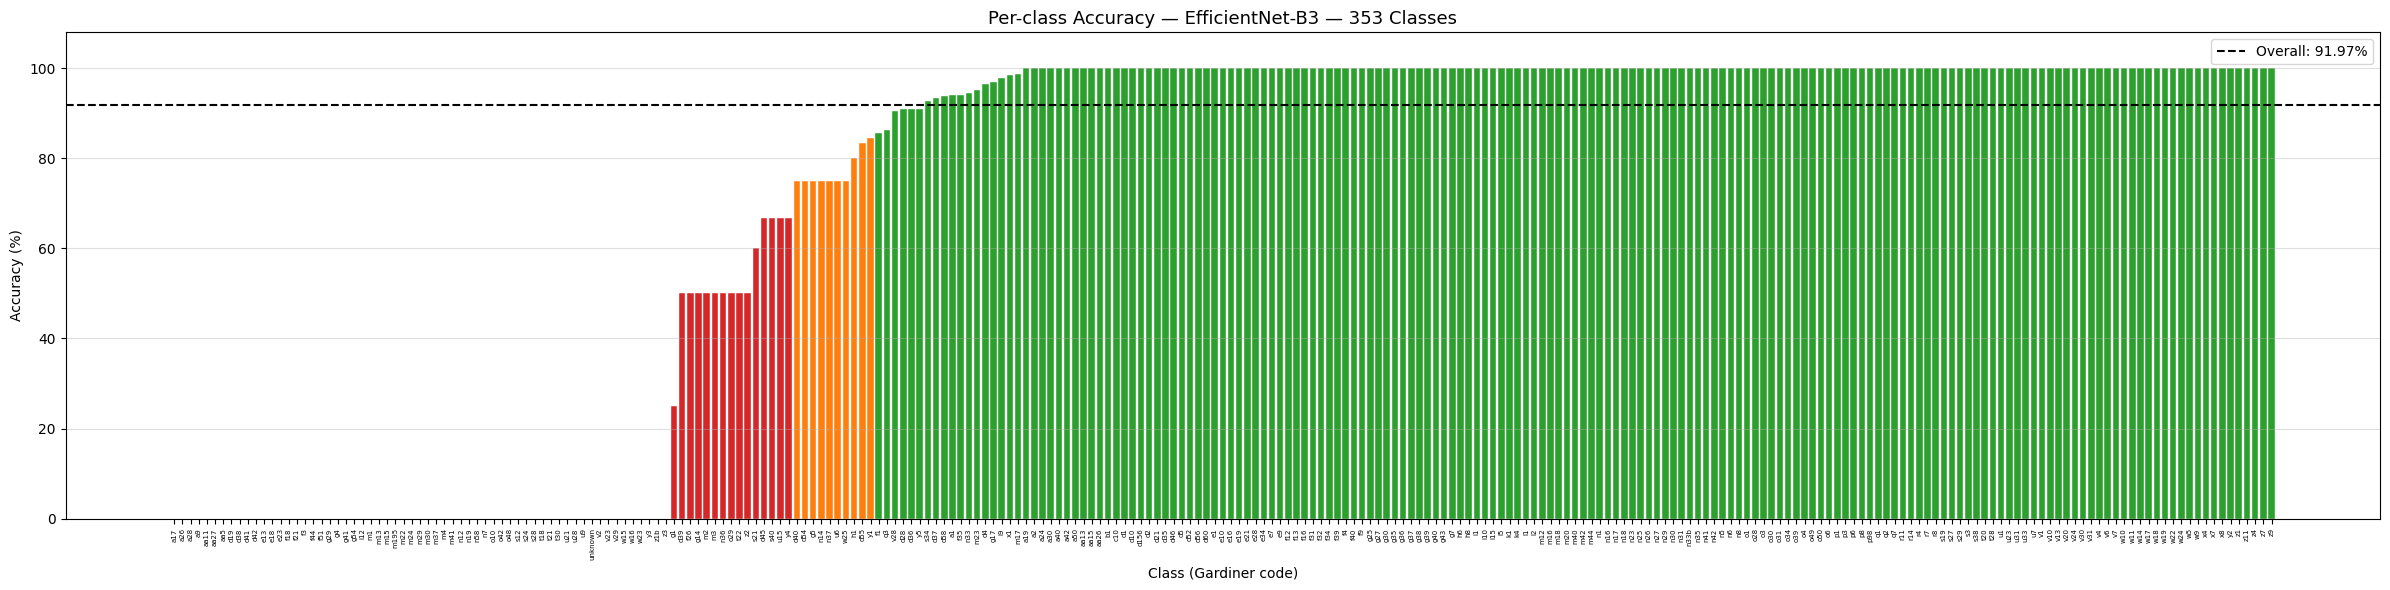


Per-class accuracy breakdown:
  >= 85% accuracy : 171 classes
  70-85% accuracy : 10 classes
  < 70% accuracy  : 76 classes

✅ Cell 6 complete!
   Saved: confusion_matrix_b3.png
   Saved: per_class_accuracy_b3.png


In [8]:
# ── CELL 6: Test Evaluation — EfficientNet-B3 ─────────────────────
import os, gc
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import models
from sklearn.metrics import (classification_report, confusion_matrix,
                              top_k_accuracy_score)

gc.collect()
torch.cuda.empty_cache()

OUTPUT      = "/kaggle/working/"
class_names = classes          # from Cell 2 — list of 353 class names
all_class_indices = list(range(num_classes))

# ── Load best model ───────────────────────────────────────────────
print("Loading EfficientNet-B3 best weights...")
model_eval = models.efficientnet_b3(weights=None)
in_features = model_eval.classifier[1].in_features
model_eval.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(in_features, 1024),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(1024, num_classes),
)
model_eval.load_state_dict(
    torch.load(OUTPUT + "efficientnet_b3_best.pth", map_location=DEVICE))
model_eval = model_eval.to(DEVICE).eval()
print("Loaded ✓")

# ── Get predictions ───────────────────────────────────────────────
all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        with torch.amp.autocast("cuda"):
            out = model_eval(imgs)
        probs = torch.softmax(out, dim=1)
        preds = out.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# ── Metrics ───────────────────────────────────────────────────────
top1 = (all_preds == all_labels).mean()
top3 = top_k_accuracy_score(all_labels, all_probs, k=3,
                             labels=all_class_indices)
top5 = top_k_accuracy_score(all_labels, all_probs, k=5,
                             labels=all_class_indices)

print("\n" + "="*55)
print(f"  TEST SET RESULTS — EfficientNet-B3")
print(f"  353 classes | {len(all_labels)} images")
print("="*55)
print(f"  Top-1 Accuracy : {top1*100:.2f}%")
print(f"  Top-3 Accuracy : {top3*100:.2f}%")
print(f"  Top-5 Accuracy : {top5*100:.2f}%")
print("="*55)

# ── Per-class report ──────────────────────────────────────────────
present_classes = sorted(set(all_labels))
present_names   = [class_names[i] for i in present_classes]

report = classification_report(
    all_labels, all_preds,
    labels=present_classes,
    target_names=present_names,
    output_dict=True, zero_division=0)

class_f1 = [(cls, report[cls]["f1-score"],
             int(report[cls]["support"]))
             for cls in present_names if cls in report]
class_f1.sort(key=lambda x: x[1])

print("\n── 10 Worst classes (F1) ────────────────────────────────────")
for cls, f1, sup in class_f1[:10]:
    print(f"  {cls:<20} F1: {f1:.3f}  support: {sup}")

print("\n── 10 Best classes (F1) ─────────────────────────────────────")
for cls, f1, sup in class_f1[-10:]:
    print(f"  {cls:<20} F1: {f1:.3f}  support: {sup}")

macro_f1    = report["macro avg"]["f1-score"]
weighted_f1 = report["weighted avg"]["f1-score"]
print(f"\n  Macro F1    : {macro_f1:.4f}")
print(f"  Weighted F1 : {weighted_f1:.4f}")

# ── Confusion matrix — top 25 classes by test support ────────────
top25_idx   = np.argsort(
    np.bincount(all_labels, minlength=num_classes))[-25:]
top25_names = [class_names[i] for i in top25_idx]
mask        = np.isin(all_labels, top25_idx)
fl          = all_labels[mask]
fp          = all_preds[mask]
remap       = {old: new for new, old in enumerate(top25_idx)}
fl_r        = np.array([remap[l] for l in fl])
fp_r        = np.array([remap[p] if p in remap else -1 for p in fp])
valid       = fp_r >= 0
cm          = confusion_matrix(fl_r[valid], fp_r[valid],
                               labels=list(range(len(top25_idx))))

fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=top25_names, yticklabels=top25_names,
            linewidths=0.5, ax=ax)
ax.set_title("Confusion Matrix — EfficientNet-B3 — Top 25 Classes",
             fontsize=13, pad=15)
ax.set_xlabel("Predicted", fontsize=11)
ax.set_ylabel("True", fontsize=11)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0,  fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT + "confusion_matrix_b3.png",
            dpi=120, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix_b3.png ✓")

# ── Per-class accuracy bar chart ──────────────────────────────────
per_class_acc = []
for i in present_classes:
    mask = all_labels == i
    if mask.sum() > 0:
        acc = (all_preds[mask] == i).mean()
        per_class_acc.append((class_names[i], acc))

per_class_acc.sort(key=lambda x: x[1])
names  = [x[0] for x in per_class_acc]
accs   = [x[1]*100 for x in per_class_acc]
colors = ['#d62728' if a < 70 else
          '#ff7f0e' if a < 85 else
          '#2ca02c' for a in accs]

fig, ax = plt.subplots(figsize=(24, 6))
ax.bar(names, accs, color=colors, edgecolor='white', linewidth=0.3)
ax.axhline(y=top1*100, color='black', linestyle='--',
           linewidth=1.5, label=f'Overall: {top1*100:.2f}%')
ax.set_title("Per-class Accuracy — EfficientNet-B3 — 353 Classes",
             fontsize=13)
ax.set_xlabel("Class (Gardiner code)")
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 108)
ax.legend(); ax.grid(axis='y', alpha=0.4)
plt.xticks(rotation=90, fontsize=5)
plt.tight_layout()
plt.savefig(OUTPUT + "per_class_accuracy_b3.png",
            dpi=120, bbox_inches='tight')
plt.show()

red    = sum(1 for a in accs if a < 70)
orange = sum(1 for a in accs if 70 <= a < 85)
green  = sum(1 for a in accs if a >= 85)
print(f"\nPer-class accuracy breakdown:")
print(f"  >= 85% accuracy : {green} classes")
print(f"  70-85% accuracy : {orange} classes")
print(f"  < 70% accuracy  : {red} classes")

print("\n✅ Cell 6 complete!")
print(f"   Saved: confusion_matrix_b3.png")
print(f"   Saved: per_class_accuracy_b3.png")

Confusion matrix size : 257 × 257
Total predictions     : 1404


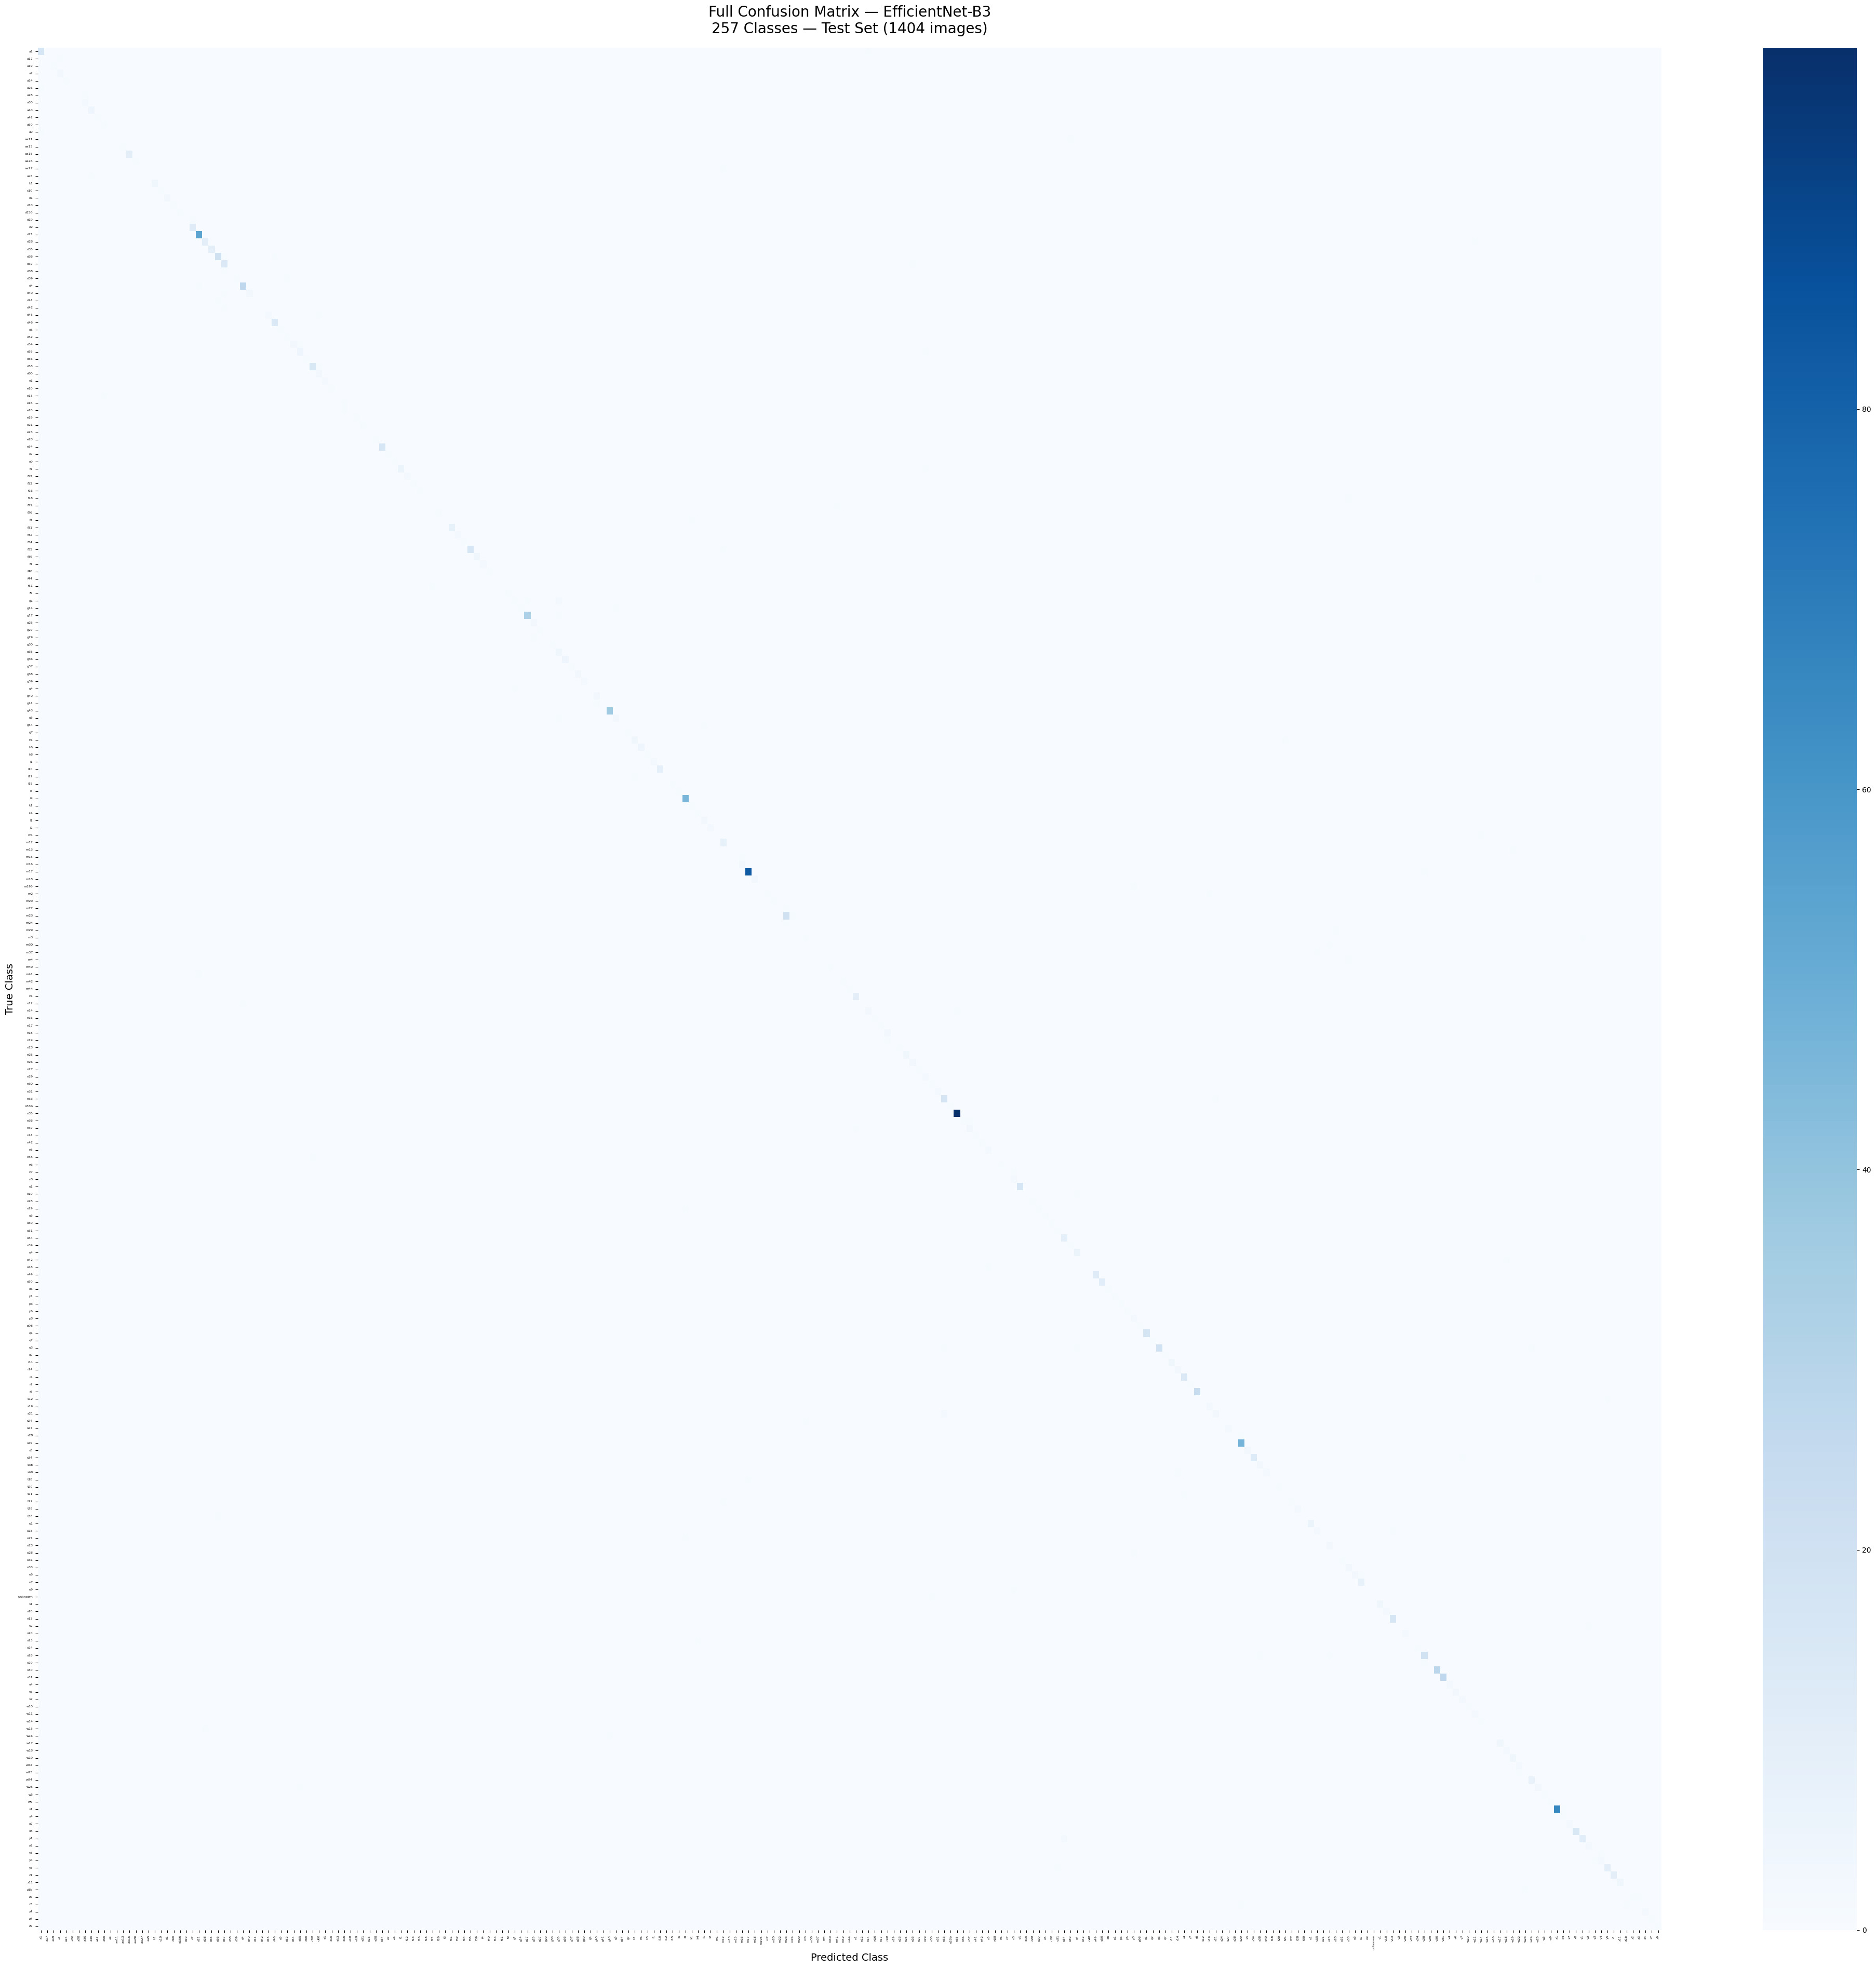

Saved: confusion_matrix_full.png ✓


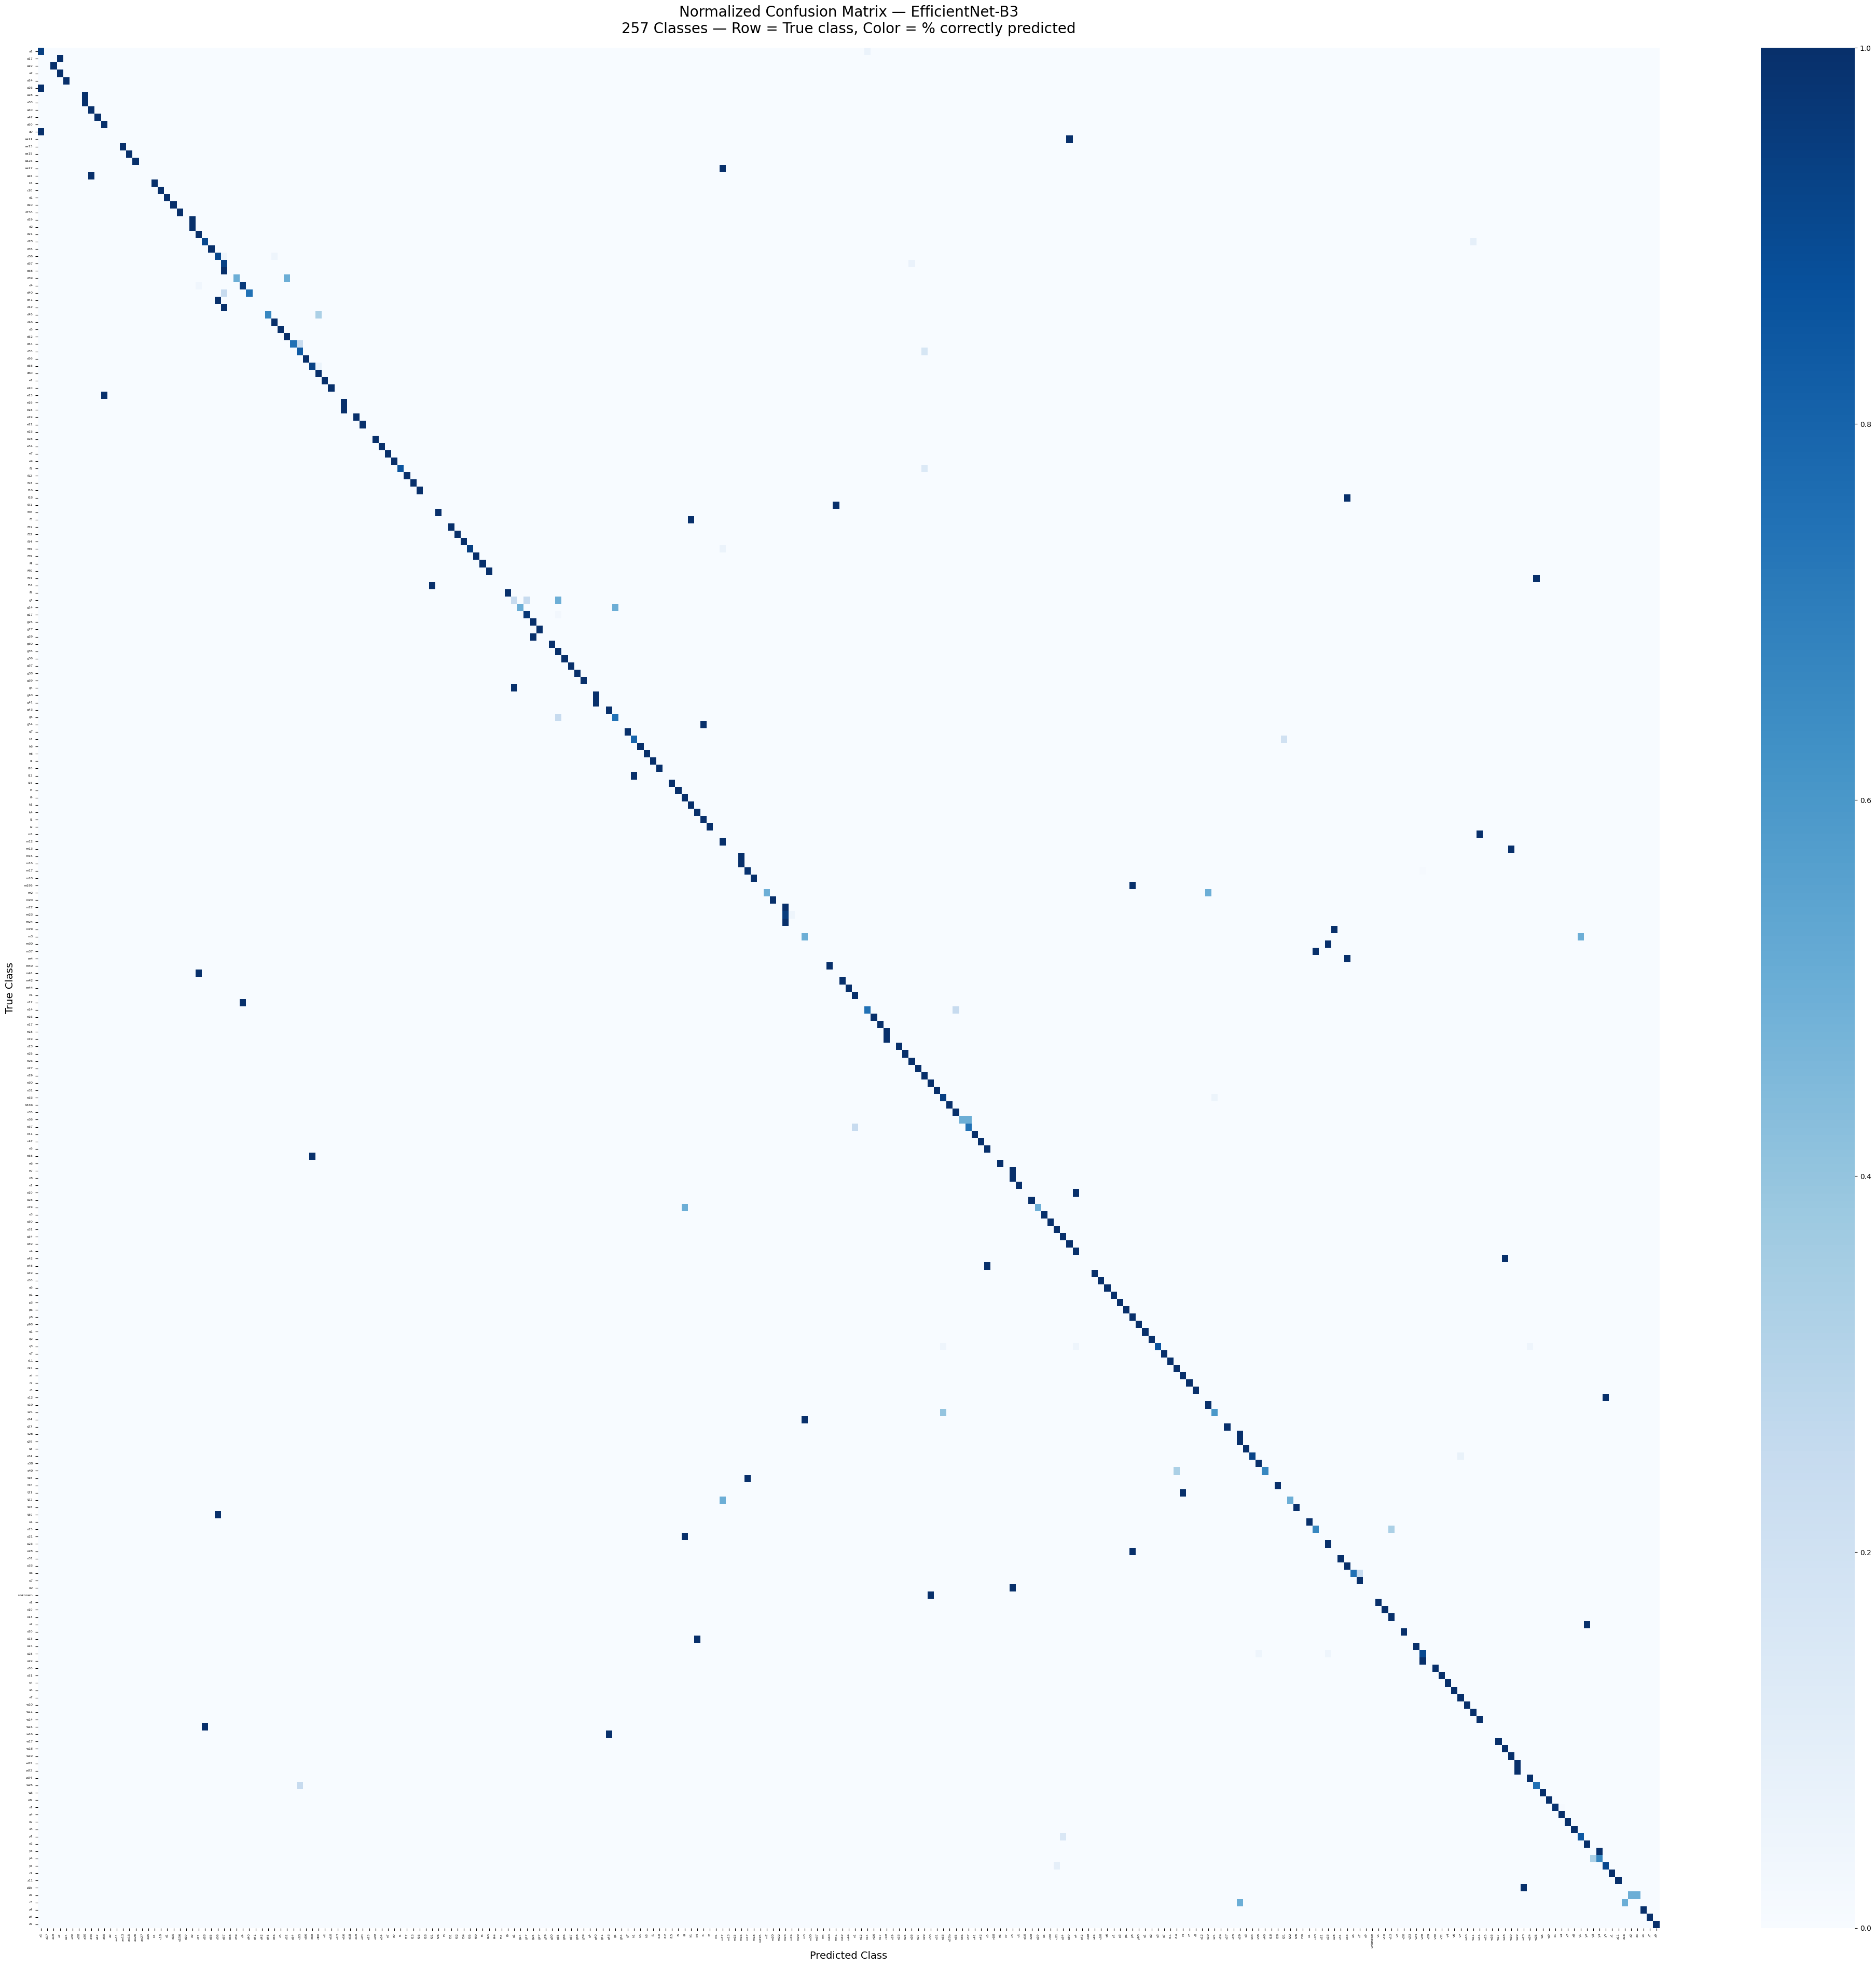

Saved: confusion_matrix_full_normalized.png ✓

── Most confused class pairs (off-diagonal) ─────────────────
  True            Predicted        Count
  ────────────────────────────────────────
  g1              → g35                2x
  s21             → n33                2x
  y1              → o34                2x
  a1              → n14                1x
  a17             → a2                 1x
  a26             → a1                 1x
  a28             → a30                1x
  a9              → a1                 1x
  aa11            → o39                1x
  aa27            → m12                1x
  aa5             → a40                1x
  d19             → d2                 1x
  d28             → w11                1x
  d36             → d37                1x
  d36             → d46                1x
  d37             → n26                1x
  d38             → d37                1x
  d39             → d52                1x
  d4              → d21                1x
  d40    

In [9]:
# ── CELL 7: Full Confusion Matrix — All 353 Classes ───────────────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import gc

gc.collect()

present_classes = sorted(set(all_labels))
present_names   = [class_names[i] for i in present_classes]
n               = len(present_classes)

remap    = {old: new for new, old in enumerate(present_classes)}
labels_r = np.array([remap[l] for l in all_labels])
preds_r  = np.array([remap[p] if p in remap else -1
                     for p in all_preds])
valid    = preds_r >= 0
cm       = confusion_matrix(labels_r[valid], preds_r[valid],
                            labels=list(range(n)))

print(f"Confusion matrix size : {n} × {n}")
print(f"Total predictions     : {valid.sum()}")

# ── Raw count heatmap ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(40, 38))
sns.heatmap(cm,
            xticklabels=present_names,
            yticklabels=present_names,
            cmap="Blues", linewidths=0,
            annot=False, cbar=True, ax=ax)
ax.set_title(
    f"Full Confusion Matrix — EfficientNet-B3\n"
    f"{n} Classes — Test Set ({valid.sum()} images)",
    fontsize=20, pad=20)
ax.set_xlabel("Predicted Class", fontsize=14)
ax.set_ylabel("True Class", fontsize=14)
plt.xticks(rotation=90, fontsize=4.5)
plt.yticks(rotation=0,  fontsize=4.5)
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_full.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix_full.png ✓")

# ── Normalized heatmap ────────────────────────────────────────────
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-6)

fig, ax = plt.subplots(figsize=(40, 38))
sns.heatmap(cm_norm,
            xticklabels=present_names,
            yticklabels=present_names,
            cmap="Blues", linewidths=0,
            vmin=0, vmax=1,
            annot=False, cbar=True, ax=ax)
ax.set_title(
    f"Normalized Confusion Matrix — EfficientNet-B3\n"
    f"{n} Classes — Row = True class, Color = % correctly predicted",
    fontsize=20, pad=20)
ax.set_xlabel("Predicted Class", fontsize=14)
ax.set_ylabel("True Class", fontsize=14)
plt.xticks(rotation=90, fontsize=4.5)
plt.yticks(rotation=0,  fontsize=4.5)
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_full_normalized.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix_full_normalized.png ✓")

# ── Most confused pairs ───────────────────────────────────────────
print("\n── Most confused class pairs (off-diagonal) ─────────────────")
print(f"  {'True':<15} {'Predicted':<15} {'Count':>6}")
print(f"  {'─'*40}")

confused_pairs = []
for i in range(n):
    for j in range(n):
        if i != j and cm[i, j] > 0:
            confused_pairs.append(
                (present_names[i], present_names[j], cm[i, j]))

confused_pairs.sort(key=lambda x: x[2], reverse=True)
for true_cls, pred_cls, count in confused_pairs[:20]:
    print(f"  {true_cls:<15} → {pred_cls:<15} {count:>4}x")

diag        = np.diag(cm)
class_total = cm.sum(axis=1)
per_acc     = np.where(class_total > 0, diag / class_total, 0)

print(f"\n── Per-class accuracy stats ─────────────────────────────────")
print(f"  Mean  : {per_acc.mean()*100:.2f}%")
print(f"  Median: {np.median(per_acc)*100:.2f}%")
print(f"  Min   : {per_acc.min()*100:.2f}% → {present_names[per_acc.argmin()]}")
print(f"  Max   : {per_acc.max()*100:.2f}%")
print("\n✅ Cell 7 complete!")

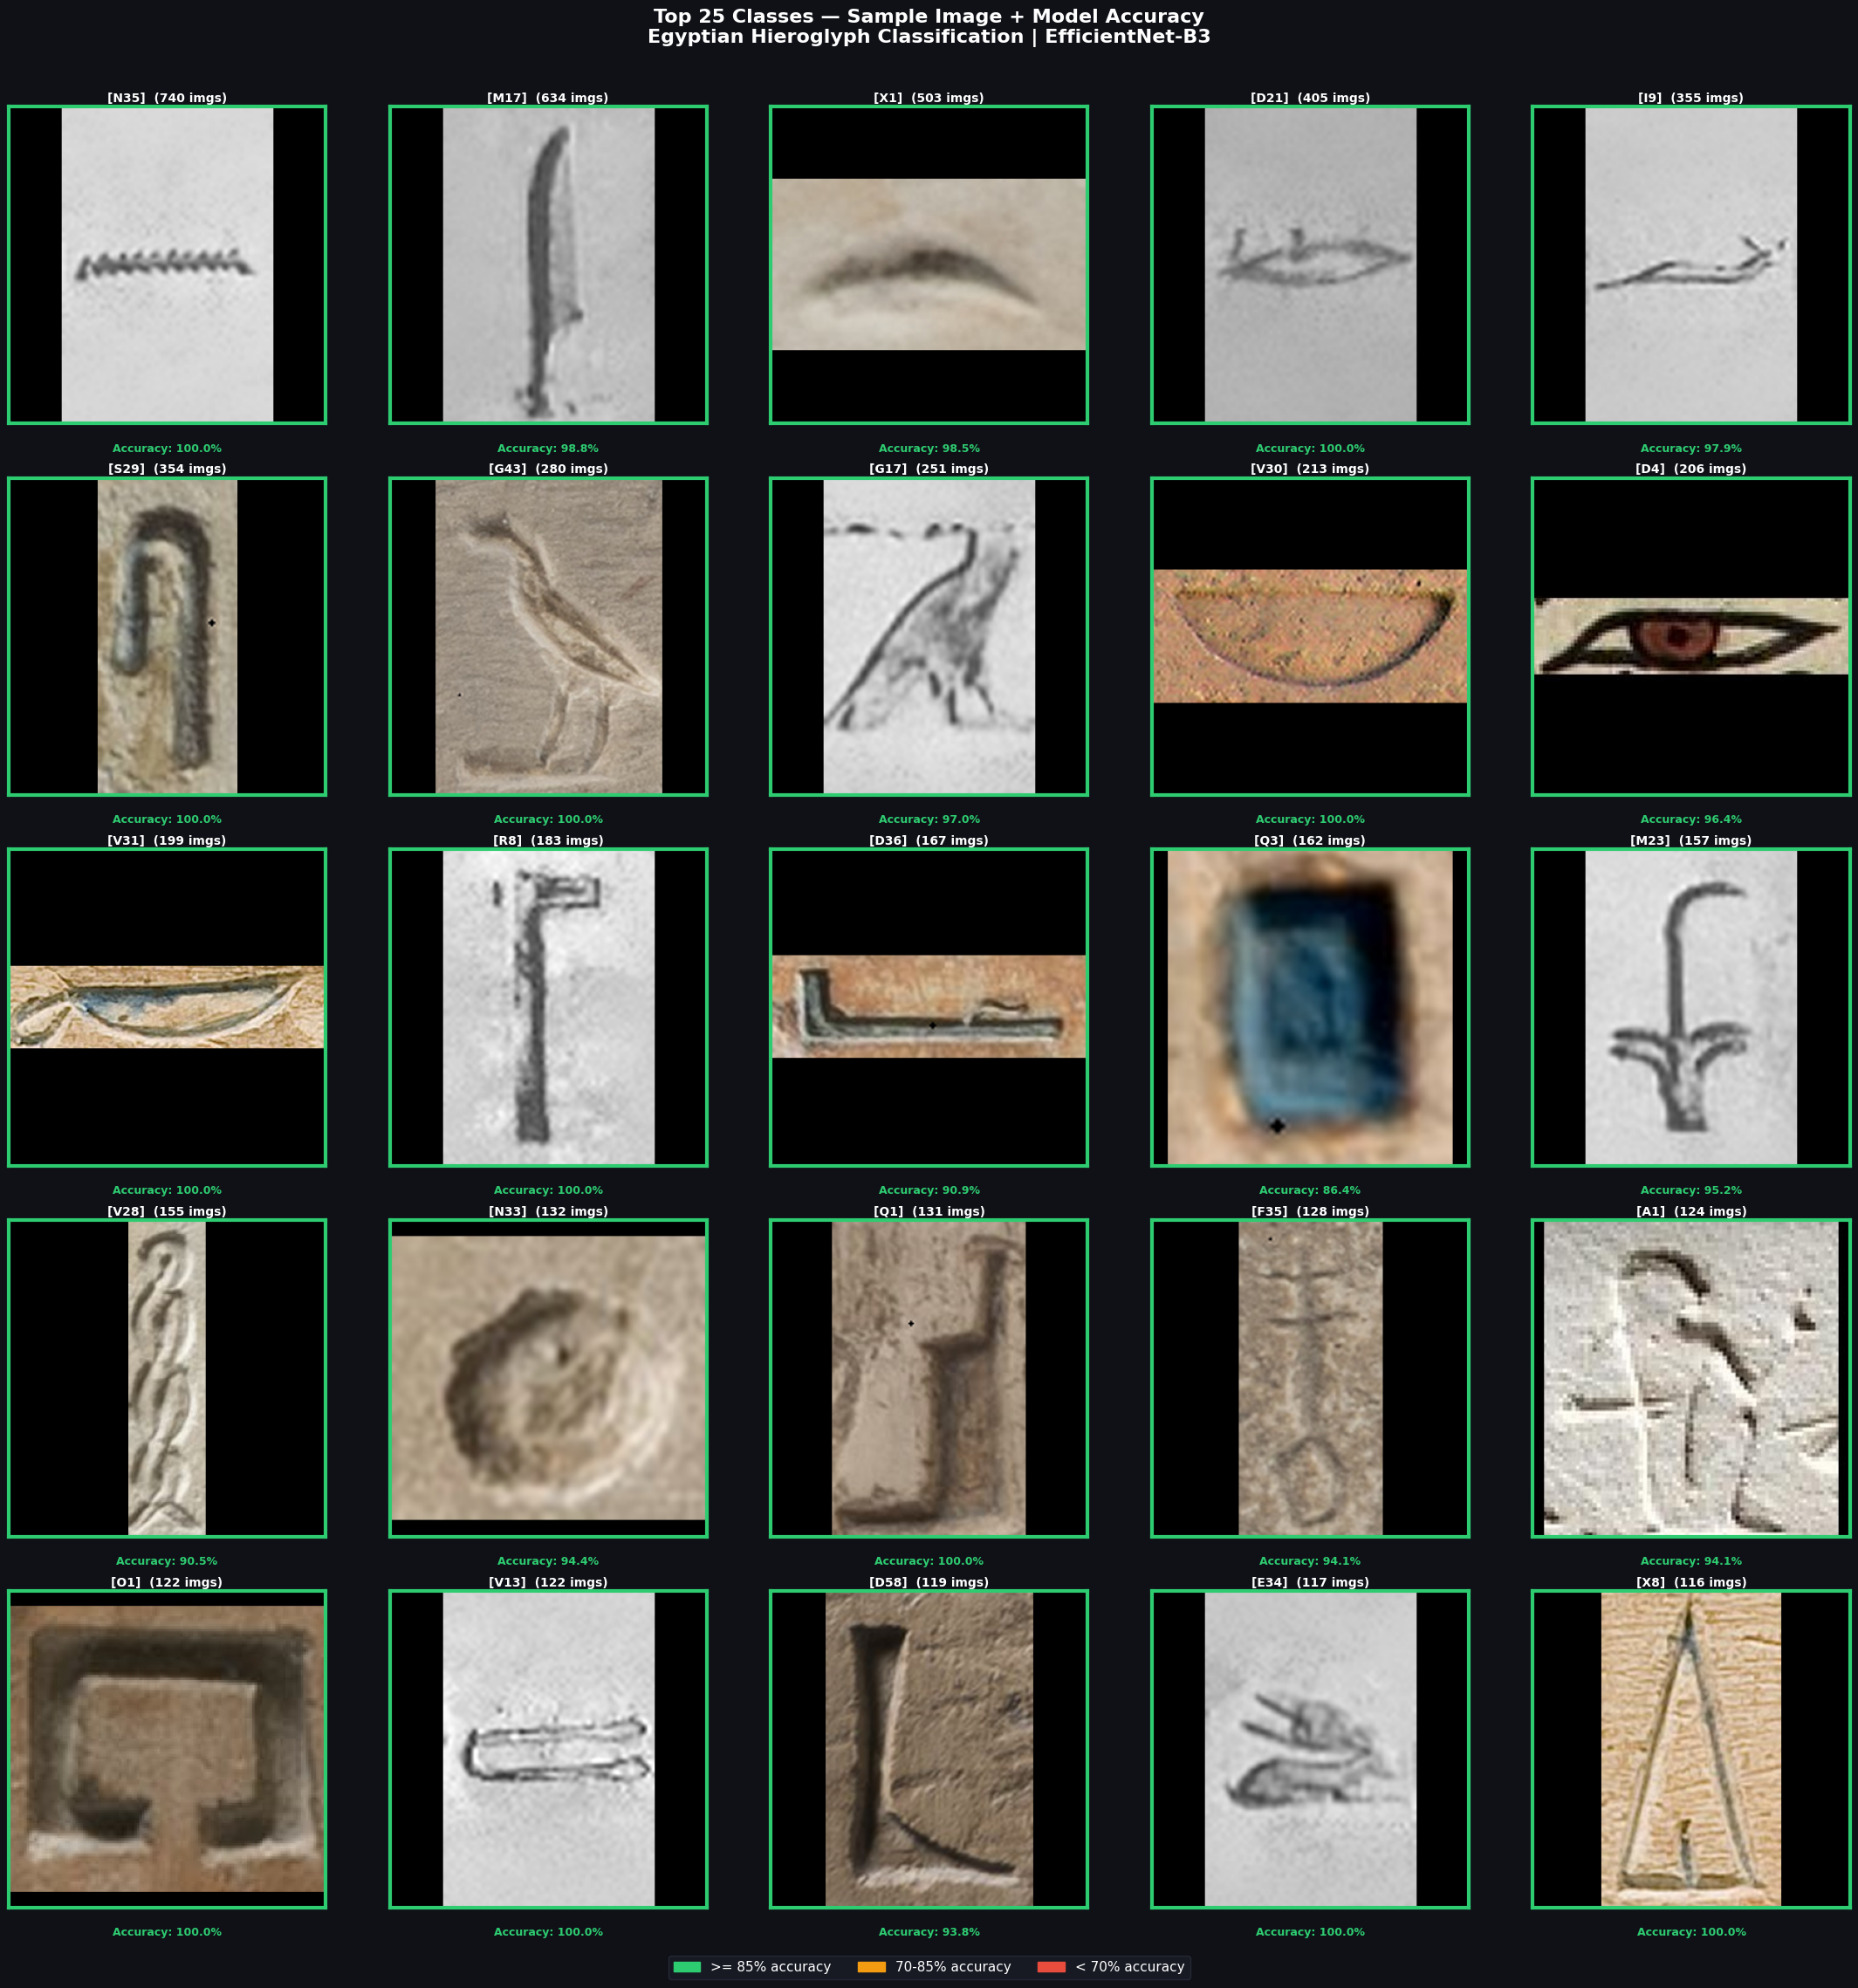

Saved: top25_predicted_classes.png ✓

── Top 25 Classes Summary ───────────────────────────────────
  Rank  Class         Images   Accuracy
  ──────────────────────────────────────
  1     n35              740    100.00%
  2     m17              634     98.81%
  3     x1               503     98.51%
  4     d21              405    100.00%
  5     i9               355     97.87%
  6     s29              354    100.00%
  7     g43              280    100.00%
  8     g17              251     96.97%
  9     v30              213    100.00%
  10    d4               206     96.43%
  11    v31              199    100.00%
  12    r8               183    100.00%
  13    d36              167     90.91%
  14    q3               162     86.36%
  15    m23              157     95.24%
  16    v28              155     90.48%
  17    n33              132     94.44%
  18    q1               131    100.00%
  19    f35              128     94.12%
  20    a1               124     94.12%
  21    o1         

In [10]:
# ── CELL 9: Display Top 25 Predicted Class Images ─────────────────
import os, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

OUTPUT       = "/kaggle/working/"
data_dir     = "/kaggle/working/GlyphTrain_Aug"   # ← fixed path

# ── Top 25 classes by image count in training set ─────────────────
class_counts = {}
for cls in class_names:
    cls_path = os.path.join(data_dir, cls)
    if os.path.isdir(cls_path):
        imgs = [f for f in os.listdir(cls_path)
                if f.lower().endswith(('.jpg','.jpeg','.png'))]
        class_counts[cls] = len(imgs)

top25_classes = sorted(class_counts.items(),
                        key=lambda x: x[1],
                        reverse=True)[:25]

# ── Per-class accuracy from Cell 6 predictions ───────────────────
class_acc = {}
for i, cls in enumerate(class_names):
    mask = all_labels == i
    if mask.sum() > 0:
        class_acc[cls] = (all_preds[mask] == i).mean() * 100
    else:
        class_acc[cls] = None

# ── Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(5, 5, figsize=(22, 22))
fig.patch.set_facecolor('#0f1117')
fig.suptitle(
    "Top 25 Classes — Sample Image + Model Accuracy\n"
    "Egyptian Hieroglyph Classification | EfficientNet-B3",
    fontsize=16, color='white', fontweight='bold', y=1.01)

for ax, (cls, count) in zip(axes.flatten(), top25_classes):
    cls_path = os.path.join(data_dir, cls)
    all_imgs  = [f for f in os.listdir(cls_path)
                 if f.lower().endswith(('.jpg','.jpeg','.png'))]
    orig_imgs = [f for f in all_imgs if not f.startswith('aug_')]
    chosen    = random.choice(orig_imgs if orig_imgs else all_imgs)

    img = Image.open(os.path.join(cls_path, chosen)).convert("RGB")
    acc = class_acc.get(cls, None)

    if acc is None:
        acc_str, bar_color = "N/A", '#8892a4'
    elif acc >= 85:
        acc_str, bar_color = f"{acc:.1f}%", '#2ecc71'
    elif acc >= 70:
        acc_str, bar_color = f"{acc:.1f}%", '#f39c12'
    else:
        acc_str, bar_color = f"{acc:.1f}%", '#e74c3c'

    ax.imshow(img)
    ax.set_facecolor('#1a1d27')
    ax.set_title(f"[{cls.upper()}]  ({count} imgs)",
                 color='white', fontsize=10,
                 fontweight='bold', pad=4)
    ax.text(0.5, -0.06, f"Accuracy: {acc_str}",
            transform=ax.transAxes,
            ha='center', va='top',
            fontsize=9, fontweight='bold', color=bar_color)
    for spine in ax.spines.values():
        spine.set_edgecolor(bar_color)
        spine.set_linewidth(3)
    ax.set_xticks([]); ax.set_yticks([])

legend_elements = [
    mpatches.Patch(color='#2ecc71', label='>= 85% accuracy'),
    mpatches.Patch(color='#f39c12', label='70-85% accuracy'),
    mpatches.Patch(color='#e74c3c', label='< 70% accuracy'),
]
fig.legend(handles=legend_elements,
           loc='lower center', ncol=3, fontsize=11,
           facecolor='#1a1d27', labelcolor='white',
           edgecolor='#2a2d3a', bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig(OUTPUT + "top25_predicted_classes.png",
            dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("Saved: top25_predicted_classes.png ✓")

# ── Summary table ─────────────────────────────────────────────────
print("\n── Top 25 Classes Summary ───────────────────────────────────")
print(f"  {'Rank':<5} {'Class':<12} {'Images':>7} {'Accuracy':>10}")
print(f"  {'─'*38}")
for rank, (cls, count) in enumerate(top25_classes, 1):
    acc = class_acc.get(cls, None)
    acc_str = f"{acc:.2f}%" if acc is not None else "N/A"
    print(f"  {rank:<5} {cls:<12} {count:>7} {acc_str:>10}")

print("\n✅ Cell 9 complete!")

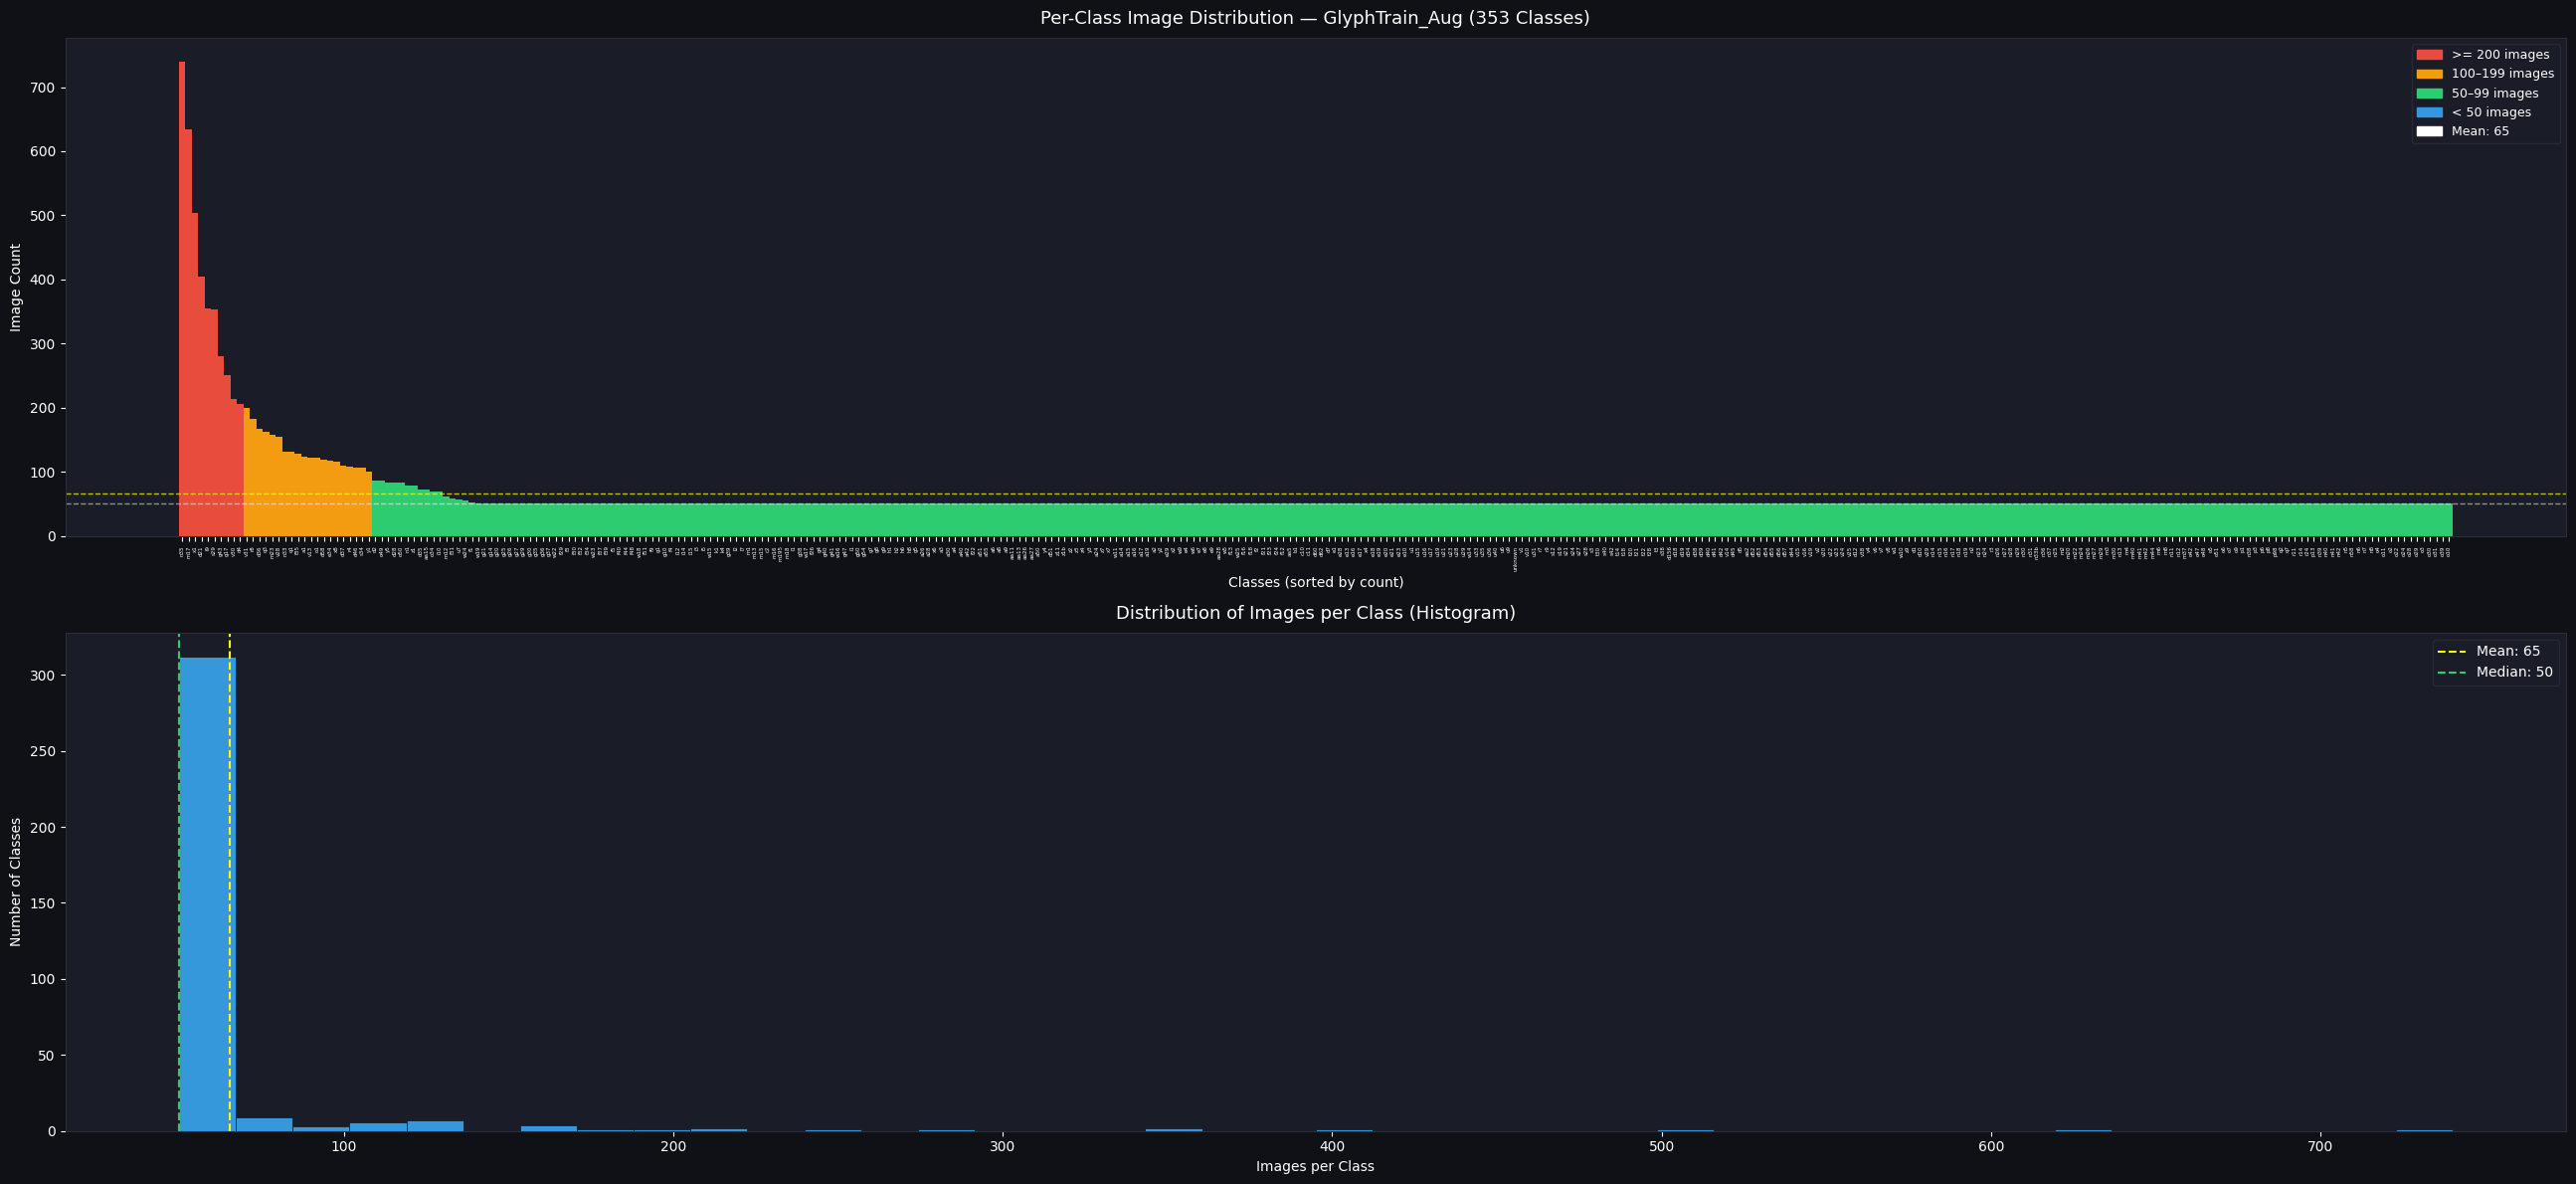

Saved: per_class_distribution.png ✓


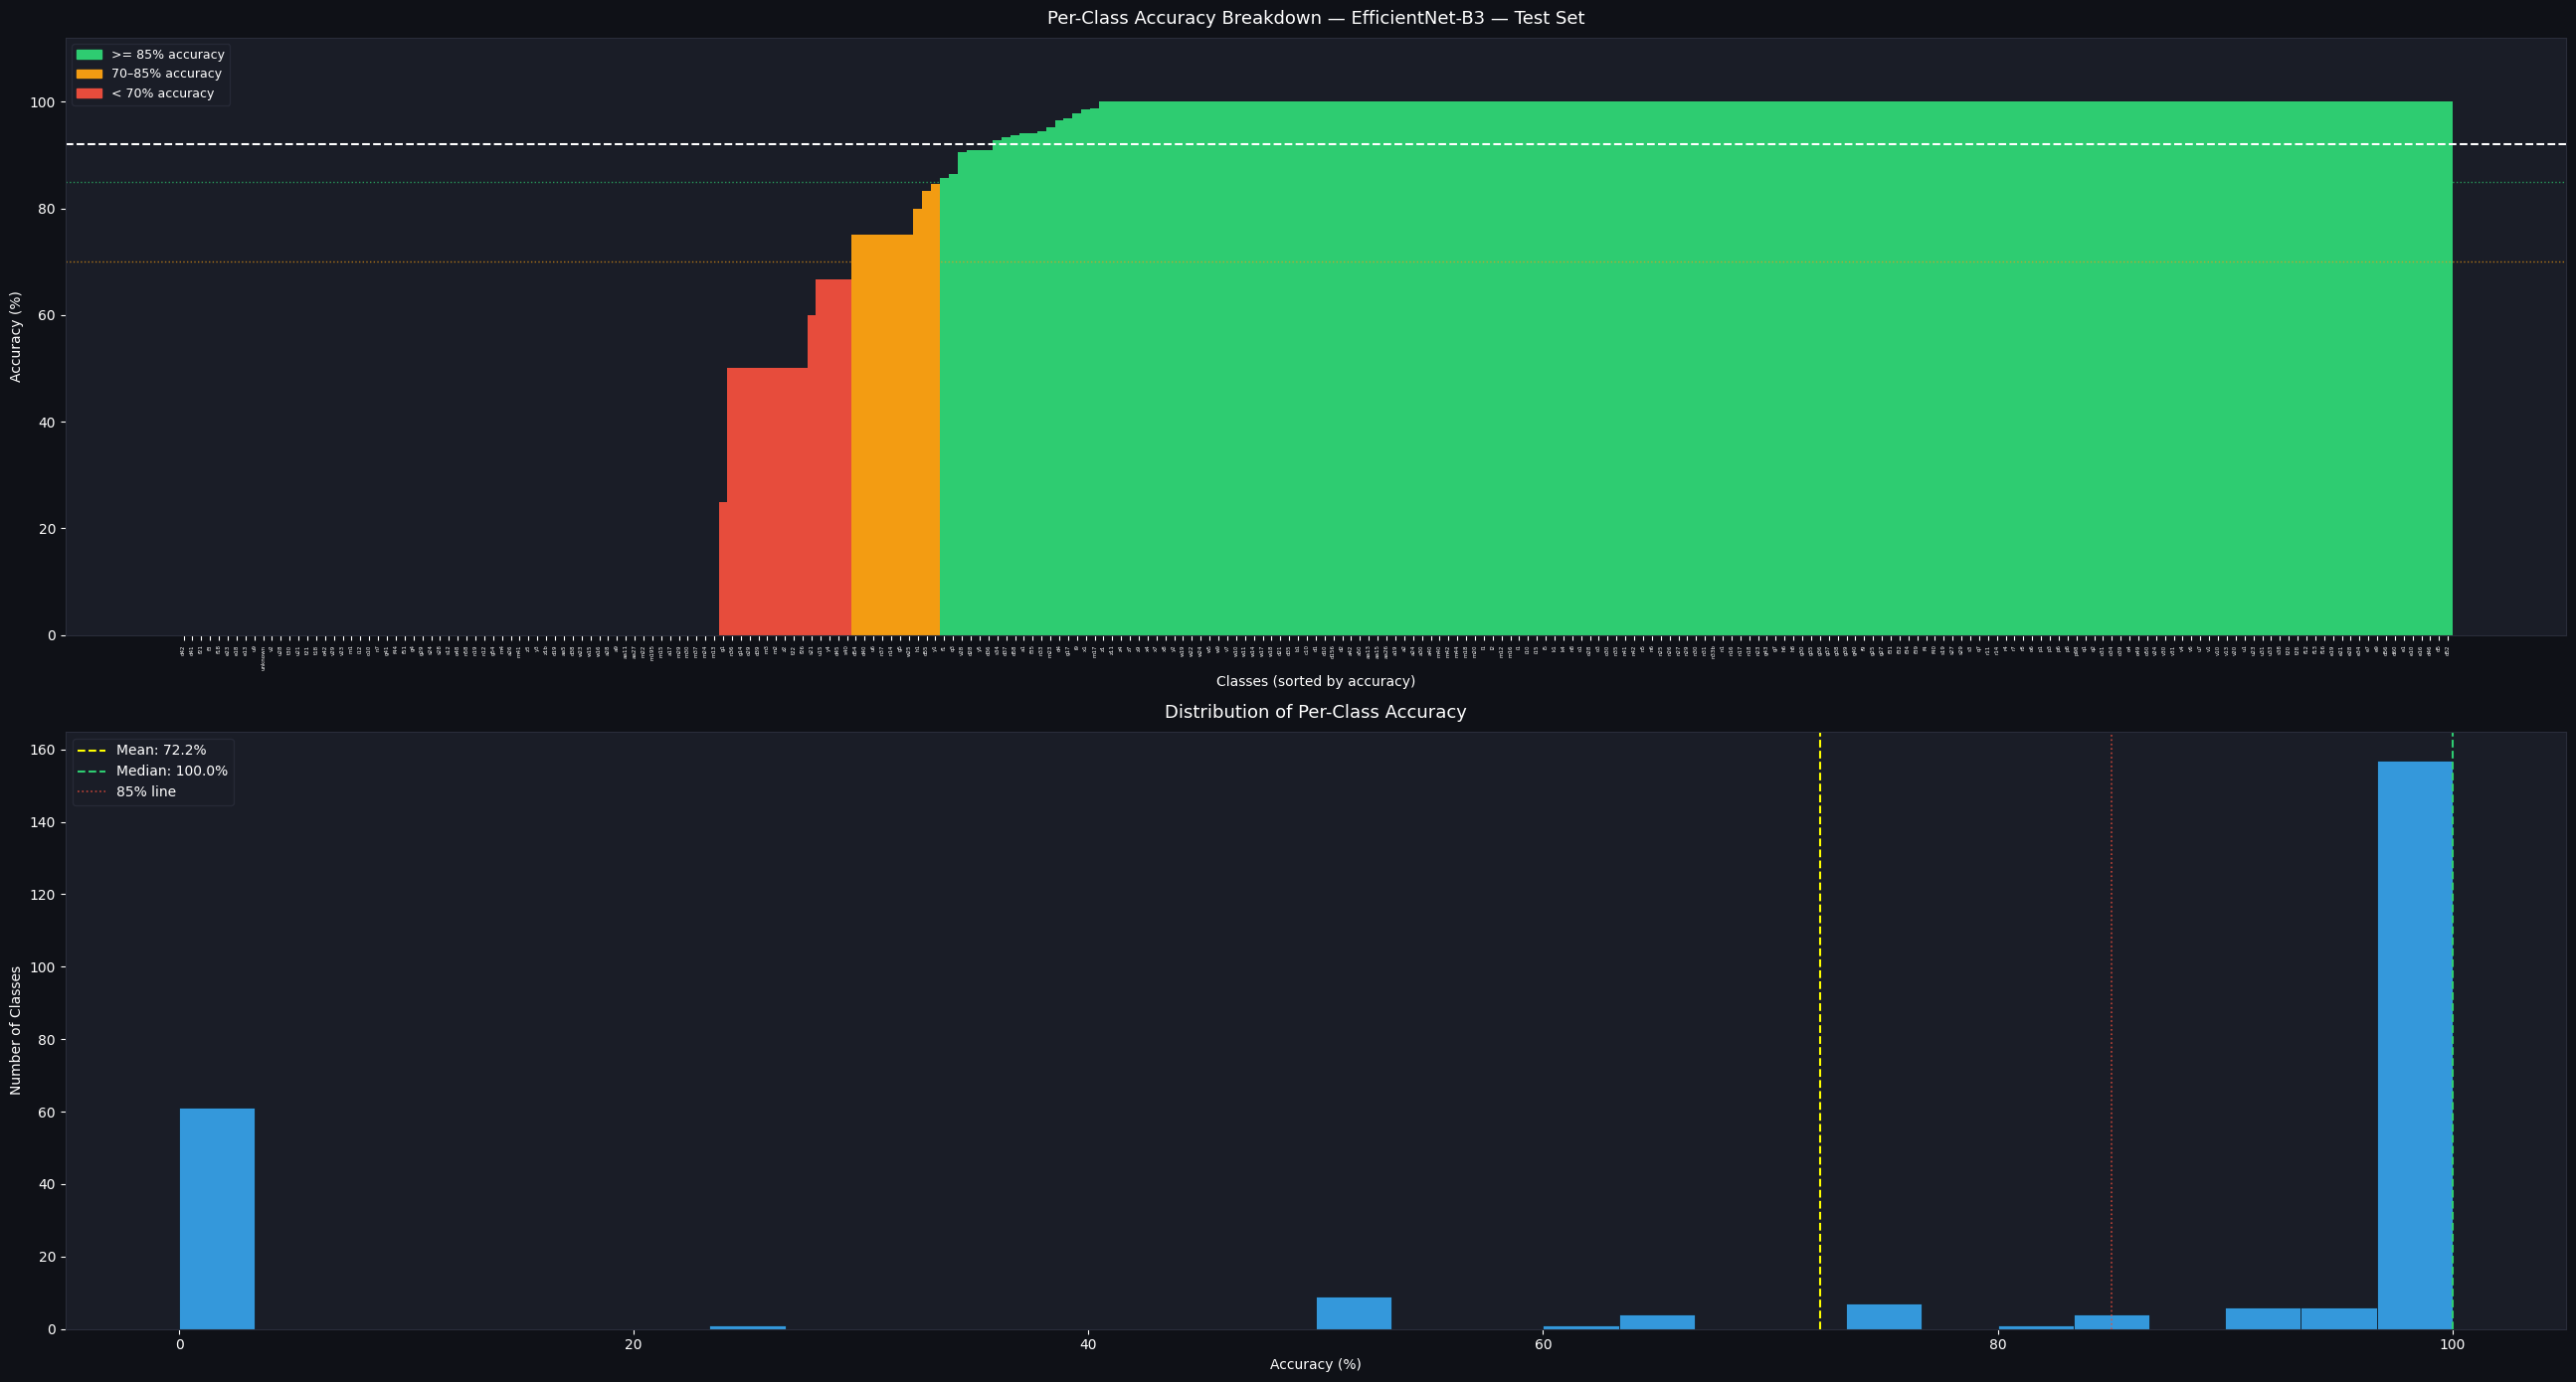

Saved: per_class_breakdown.png ✓

── Per-Class Accuracy Summary ───────────────────────────────
  Mean accuracy   : 72.20%
  Median accuracy : 100.00%
  >= 85% accuracy : 171  classes
  70-85% accuracy : 10  classes
  < 70%  accuracy : 76  classes
  Best class      : d52 (100.0%)
  Worst class     : d42  (0.0%)

✅ Cell 10 complete!


In [11]:
# ── CELL 10: Per-Class Distribution + Breakdown Curves ────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

OUTPUT = "/kaggle/working/"

# ── 1. Per-Class Image Distribution (Training Set) ────────────────
aug_counts = np.array([
    len([f for f in os.listdir(os.path.join("/kaggle/working/GlyphTrain_Aug", cls))
         if f.lower().endswith(('.jpg','.jpeg','.png'))])
    for cls in class_names
    if os.path.isdir(os.path.join("/kaggle/working/GlyphTrain_Aug", cls))
])

sorted_counts = np.sort(aug_counts)[::-1]
sorted_names  = [class_names[i] for i in np.argsort(aug_counts)[::-1]]

fig, axes = plt.subplots(2, 1, figsize=(26, 12))
fig.patch.set_facecolor('#0f1117')

# ── Top plot: bar chart of all classes sorted by count ────────────
colors = ['#e74c3c' if c >= 200 else
          '#f39c12' if c >= 100 else
          '#2ecc71' if c >= 50  else
          '#3498db' for c in sorted_counts]

axes[0].bar(range(len(sorted_counts)), sorted_counts,
            color=colors, edgecolor='none', width=1.0)
axes[0].axhline(y=50,  color='white', linestyle='--',
                linewidth=1, alpha=0.5, label='Min target (50)')
axes[0].axhline(y=aug_counts.mean(), color='yellow',
                linestyle='--', linewidth=1,
                alpha=0.7, label=f'Mean ({aug_counts.mean():.0f})')
axes[0].set_facecolor('#1a1d27')
axes[0].set_title("Per-Class Image Distribution — GlyphTrain_Aug (353 Classes)",
                  color='white', fontsize=13, pad=10)
axes[0].set_xlabel("Classes (sorted by count)", color='white', fontsize=10)
axes[0].set_ylabel("Image Count", color='white', fontsize=10)
axes[0].tick_params(colors='white')
axes[0].set_xticks(range(len(sorted_names)))
axes[0].set_xticklabels(sorted_names, rotation=90,
                         fontsize=4, color='white')
for spine in axes[0].spines.values():
    spine.set_edgecolor('#2a2d3a')

legend_elements = [
    mpatches.Patch(color='#e74c3c', label='>= 200 images'),
    mpatches.Patch(color='#f39c12', label='100–199 images'),
    mpatches.Patch(color='#2ecc71', label='50–99 images'),
    mpatches.Patch(color='#3498db', label='< 50 images'),
    mpatches.Patch(color='white',   label=f'Mean: {aug_counts.mean():.0f}'),
]
axes[0].legend(handles=legend_elements, loc='upper right',
               facecolor='#1a1d27', labelcolor='white',
               edgecolor='#2a2d3a', fontsize=9)

# ── Bottom plot: histogram of image counts ────────────────────────
axes[1].hist(aug_counts, bins=40, color='#3498db',
             edgecolor='#0f1117', linewidth=0.5)
axes[1].axvline(x=aug_counts.mean(),   color='yellow',
                linestyle='--', linewidth=1.5,
                label=f'Mean: {aug_counts.mean():.0f}')
axes[1].axvline(x=np.median(aug_counts), color='#2ecc71',
                linestyle='--', linewidth=1.5,
                label=f'Median: {np.median(aug_counts):.0f}')
axes[1].set_facecolor('#1a1d27')
axes[1].set_title("Distribution of Images per Class (Histogram)",
                  color='white', fontsize=13, pad=10)
axes[1].set_xlabel("Images per Class", color='white', fontsize=10)
axes[1].set_ylabel("Number of Classes", color='white', fontsize=10)
axes[1].tick_params(colors='white')
axes[1].legend(facecolor='#1a1d27', labelcolor='white',
               edgecolor='#2a2d3a', fontsize=10)
for spine in axes[1].spines.values():
    spine.set_edgecolor('#2a2d3a')

fig.patch.set_facecolor('#0f1117')
plt.tight_layout()
plt.savefig(OUTPUT + "per_class_distribution.png",
            dpi=120, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print("Saved: per_class_distribution.png ✓")

# ── 2. Per-Class Accuracy Breakdown ──────────────────────────────
present_classes = sorted(set(all_labels))
per_class_acc_vals = []
per_class_names    = []

for i in present_classes:
    mask = all_labels == i
    if mask.sum() > 0:
        acc = (all_preds[mask] == i).mean() * 100
        per_class_acc_vals.append(acc)
        per_class_names.append(class_names[i])

sorted_idx   = np.argsort(per_class_acc_vals)
sorted_accs  = np.array(per_class_acc_vals)[sorted_idx]
sorted_cls   = np.array(per_class_names)[sorted_idx]

bar_colors = ['#e74c3c' if a < 70 else
              '#f39c12' if a < 85 else
              '#2ecc71' for a in sorted_accs]

fig, axes = plt.subplots(2, 1, figsize=(26, 14))
fig.patch.set_facecolor('#0f1117')

# ── Top: full bar chart sorted by accuracy ────────────────────────
axes[0].bar(range(len(sorted_accs)), sorted_accs,
            color=bar_colors, edgecolor='none', width=1.0)
axes[0].axhline(y=(all_preds == all_labels).mean()*100,
                color='white', linestyle='--', linewidth=1.5,
                label=f'Overall: {(all_preds==all_labels).mean()*100:.2f}%')
axes[0].axhline(y=85, color='#2ecc71', linestyle=':',
                linewidth=1, alpha=0.7, label='85% threshold')
axes[0].axhline(y=70, color='#f39c12', linestyle=':',
                linewidth=1, alpha=0.7, label='70% threshold')
axes[0].set_facecolor('#1a1d27')
axes[0].set_title("Per-Class Accuracy Breakdown — EfficientNet-B3 — Test Set",
                  color='white', fontsize=13, pad=10)
axes[0].set_xlabel("Classes (sorted by accuracy)", color='white', fontsize=10)
axes[0].set_ylabel("Accuracy (%)", color='white', fontsize=10)
axes[0].set_ylim(0, 112)
axes[0].tick_params(colors='white')
axes[0].set_xticks(range(len(sorted_cls)))
axes[0].set_xticklabels(sorted_cls, rotation=90,
                         fontsize=4, color='white')
for spine in axes[0].spines.values():
    spine.set_edgecolor('#2a2d3a')

legend_elems = [
    mpatches.Patch(color='#2ecc71', label='>= 85% accuracy'),
    mpatches.Patch(color='#f39c12', label='70–85% accuracy'),
    mpatches.Patch(color='#e74c3c', label='< 70% accuracy'),
]
axes[0].legend(handles=legend_elems, loc='upper left',
               facecolor='#1a1d27', labelcolor='white',
               edgecolor='#2a2d3a', fontsize=9)

# ── Bottom: accuracy histogram ────────────────────────────────────
axes[1].hist(sorted_accs, bins=30, color='#3498db',
             edgecolor='#0f1117', linewidth=0.5)
axes[1].axvline(x=np.mean(sorted_accs), color='yellow',
                linestyle='--', linewidth=1.5,
                label=f'Mean: {np.mean(sorted_accs):.1f}%')
axes[1].axvline(x=np.median(sorted_accs), color='#2ecc71',
                linestyle='--', linewidth=1.5,
                label=f'Median: {np.median(sorted_accs):.1f}%')
axes[1].axvline(x=85, color='#e74c3c', linestyle=':',
                linewidth=1.2, alpha=0.8, label='85% line')
axes[1].set_facecolor('#1a1d27')
axes[1].set_title("Distribution of Per-Class Accuracy",
                  color='white', fontsize=13, pad=10)
axes[1].set_xlabel("Accuracy (%)", color='white', fontsize=10)
axes[1].set_ylabel("Number of Classes", color='white', fontsize=10)
axes[1].tick_params(colors='white')
axes[1].legend(facecolor='#1a1d27', labelcolor='white',
               edgecolor='#2a2d3a', fontsize=10)
for spine in axes[1].spines.values():
    spine.set_edgecolor('#2a2d3a')

plt.tight_layout()
plt.savefig(OUTPUT + "per_class_breakdown.png",
            dpi=120, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print("Saved: per_class_breakdown.png ✓")

# ── Stats summary ─────────────────────────────────────────────────
green  = sum(1 for a in sorted_accs if a >= 85)
orange = sum(1 for a in sorted_accs if 70 <= a < 85)
red    = sum(1 for a in sorted_accs if a < 70)

print(f"\n── Per-Class Accuracy Summary ───────────────────────────────")
print(f"  Mean accuracy   : {np.mean(sorted_accs):.2f}%")
print(f"  Median accuracy : {np.median(sorted_accs):.2f}%")
print(f"  >= 85% accuracy : {green}  classes")
print(f"  70-85% accuracy : {orange}  classes")
print(f"  < 70%  accuracy : {red}  classes")
print(f"  Best class      : {sorted_cls[-1]} ({sorted_accs[-1]:.1f}%)")
print(f"  Worst class     : {sorted_cls[0]}  ({sorted_accs[0]:.1f}%)")
print("\n✅ Cell 10 complete!")

In [12]:
# ── CELL 11: Save Model + All Project Outputs ─────────────────────
import os, json, shutil, zipfile
import numpy as np
import torch

OUTPUT = "/kaggle/working/"

print("="*55)
print("  Saving all project outputs...")
print("="*55)

# ── 1. Save full model checkpoint (weights + meta) ────────────────
torch.save({
    "model_state_dict" : model_eval.state_dict(),
    "num_classes"      : num_classes,
    "class_names"      : class_names,
    "best_val_acc"     : 0.9203,
    "best_epoch"       : 58,
    "architecture"     : "efficientnet_b3",
    "img_size"         : 300,
    "train_acc_final"  : history["train_acc"][-1],
    "val_acc_final"    : history["val_acc"][-1],
}, OUTPUT + "efficientnet_b3_full_checkpoint.pth")
print("Saved: efficientnet_b3_full_checkpoint.pth ✓")

# ── 2. Save class names JSON (already saved — verify) ─────────────
with open(OUTPUT + "class_names.json") as f:
    meta = json.load(f)
print(f"Verified: class_names.json ({meta['num_classes']} classes) ✓")

# ── 3. Save training history JSON (already saved — verify) ────────
with open(OUTPUT + "efficientnet_b3_history.json") as f:
    hist = json.load(f)
print(f"Verified: efficientnet_b3_history.json "
      f"({len(hist['train_loss'])} epochs) ✓")

# ── 4. Save test predictions ──────────────────────────────────────
np.save(OUTPUT + "test_preds.npy",   all_preds)
np.save(OUTPUT + "test_labels.npy",  all_labels)
np.save(OUTPUT + "test_probs.npy",   all_probs)
print("Saved: test_preds.npy  ✓")
print("Saved: test_labels.npy ✓")
print("Saved: test_probs.npy  ✓")

# ── 5. Save split arrays (already saved — verify) ─────────────────
for name in ["split_X_train", "split_X_val", "split_X_test",
             "split_y_train", "split_y_val", "split_y_test"]:
    path = OUTPUT + name + ".npy"
    size = os.path.getsize(path) / 1024
    print(f"Verified: {name}.npy ({size:.1f} KB) ✓")

# ── 6. List all saved output files ───────────────────────────────
print("\n── All output files ─────────────────────────────────────────")
output_files = sorted(os.listdir(OUTPUT))
total_size   = 0
for fname in output_files:
    fpath = os.path.join(OUTPUT, fname)
    if os.path.isfile(fpath):
        size = os.path.getsize(fpath)
        total_size += size
        print(f"  {fname:<50} {size/1024/1024:>7.2f} MB")

print(f"\n  Total size : {total_size/1024/1024:.2f} MB")

# ── 7. Zip all key outputs into one downloadable archive ──────────
zip_path = OUTPUT + "Glyph2025_EfficientNetB3_outputs.zip"
key_files = [
    "efficientnet_b3_best.pth",
    "efficientnet_b3_full_checkpoint.pth",
    "efficientnet_b3_history.json",
    "class_names.json",
    "test_preds.npy",
    "test_labels.npy",
    "test_probs.npy",
    "efficientnet_b3_curves.png",
    "confusion_matrix_b3.png",
    "confusion_matrix_full.png",
    "confusion_matrix_full_normalized.png",
    "per_class_accuracy_b3.png",
    "per_class_distribution.png",
    "per_class_breakdown.png",
    "top25_predicted_classes.png",
]

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in key_files:
        fpath = os.path.join(OUTPUT, fname)
        if os.path.exists(fpath):
            zf.write(fpath, fname)
            print(f"  Zipped: {fname}")
        else:
            print(f"  MISSING: {fname}")

zip_size = os.path.getsize(zip_path) / 1024 / 1024
print(f"\nSaved: Glyph2025_EfficientNetB3_outputs.zip "
      f"({zip_size:.2f} MB) ✓")

print("\n" + "="*55)
print("✅ All outputs saved!")
print(f"   Model     : efficientnet_b3_best.pth")
print(f"   Checkpoint: efficientnet_b3_full_checkpoint.pth")
print(f"   Archive   : Glyph2025_EfficientNetB3_outputs.zip")
print(f"   Epochs    : {len(hist['train_loss'])}")
print(f"   Best Val  : 92.03% (epoch 58)")
print("="*55)

  Saving all project outputs...
Saved: efficientnet_b3_full_checkpoint.pth ✓
Verified: class_names.json (353 classes) ✓
Verified: efficientnet_b3_history.json (73 epochs) ✓
Saved: test_preds.npy  ✓
Saved: test_labels.npy ✓
Saved: test_probs.npy  ✓
Verified: split_X_train.npy (2077.5 KB) ✓
Verified: split_X_val.npy (428.3 KB) ✓
Verified: split_X_test.npy (285.9 KB) ✓
Verified: split_y_train.npy (80.0 KB) ✓
Verified: split_y_val.npy (16.6 KB) ✓
Verified: split_y_test.npy (11.1 KB) ✓

── All output files ─────────────────────────────────────────
  class_names.json                                      0.01 MB
  classification_report.txt                             0.01 MB
  cm_all_classes.png                                    0.15 MB
  cm_top25.png                                          0.07 MB
  confusion_matrix_b3.png                               0.10 MB
  confusion_matrix_full.png                             0.30 MB
  confusion_matrix_full_normalized.png                  0.31 MB
  e